#### Importing libary

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
pd.set_option("display.max_columns", None)

from itertools import combinations

import networkx as nx
import numpy as np
from sklearn.metrics import f1_score

from pgmpy.estimators import PC, HillClimbSearch
from pgmpy.utils import get_example_model
#from pgmpy.metrics import structural_hamming_distance as shd
from pgmpy import utils as pg_utils
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import time
import warnings
warnings.filterwarnings("ignore")


import seaborn as sns

%matplotlib inline

### Loading the data

#### Context 

`Diabetes` is among the most prevalent chronic diseases in the world, impacting millions of individuals each year and exerting a significant financial burden on the economy. Diabetes is a serious chronic disease in which individuals lose the ability to effectively regulate levels of glucose in the blood, and can lead to reduced quality of life and life expectancy. After different foods are broken down into sugars during digestion, the sugars are then released into the bloodstream. This signals the pancreas to release insulin. Insulin helps enable cells within the body to use those sugars in the bloodstream for energy. Diabetes is generally characterized by either the body not making enough insulin or being unable to use the insulin that is made as effectively as needed.

Complications like heart disease, vision loss, lower-limb amputation, and kidney disease are associated with chronically high levels of sugar remaining in the bloodstream for those with diabetes. While there is no cure for diabetes, strategies like losing weight, eating healthily, being active, and receiving medical treatments can mitigate the harms of this disease in many patients. Early diagnosis can lead to lifestyle changes and more effective treatment, making predictive models for diabetes risk important tools for public and public health officials.

The scale of this problem is also important to recognise. The Centers for Disease Control and Prevention has indicated that as of 2018, 34.2 million individuals have diabetes and 88 million have prediabetes. Furthermore, the CDC estimates that 1 in 5 diabetics, and roughly 8 in 10 prediabetics are unaware of their risk. While there are different types of diabetes, type II diabetes is the most common form and its prevalence varies by age, education, income, location, race, and other social determinants of health. Much of the burden of the disease falls on those of lower socioeconomic status as well. Diabetes also places a massive burden on the economy, with diagnosed diabetes costs of roughly $327 billion dollars and total costs with undiagnosed diabetes and prediabetes approaching $400 billion dollars annually.

The Behavioral Risk Factor Surveillance System (BRFSS) is a health-related telephone survey that is collected annually by the CDC. Each year, the survey collects responses from over 400,000 Americans on health-related risk behaviors, chronic health conditions, and the use of preventative services. It has been conducted every year since 1984. For this project, a csv of the dataset available on Kaggle for the year 2015 was used. This original dataset contains responses from 441,455 individuals and has 330 features. These features are either questions directly asked of participants, or calculated variables based on individual participant responses.

This dataset contains 3 files:

1. diabetes _ 012 _ health _ indicators _ BRFSS2015.csv is a clean dataset of 253,680 survey responses to the CDC's BRFSS2015. The target variable Diabetes_012 has 3 classes. 0 is for no diabetes or only during pregnancy, 1 is for prediabetes, and 2 is for diabetes. There is class imbalance in this dataset. This dataset has 21 feature variables.

2. diabetes _ binary _ 5050split _ health _ indicators _ BRFSS2015.csv is a clean dataset of 70,692 survey responses to the CDC's BRFSS2015. It has an equal 50-50 split of respondents with no diabetes and with either prediabetes or diabetes. The target variable Diabetes_binary has 2 classes. 0 is for no diabetes, and 1 is for prediabetes or diabetes. This dataset has 21 feature variables and is balanced.

3. diabetes _ binary _ health _ indicators _ BRFSS2015.csv is a clean dataset of 253,680 survey responses to the CDC's BRFSS2015. The target variable Diabetes_binary has 2 classes. 0 is for no diabetes, and 1 is for prediabetes or diabetes. This dataset has 21 feature variables and is not balanced.

----

In [29]:
df = pd.read_csv('Diabetes Health Indicators/diabetes_binary_health_indicators_BRFSS2015.csv')

#### Variable Description

## Variables Table

| Variable Name | Role | Type | Demographic | Description | Units | Missing Values |
|--------------|------|------|-------------|-------------|-------|----------------|
| ID | ID | Integer |  | Patient ID |  | no |
| Diabetes_binary | Target | Binary |  | 0 = no diabetes, 1 = prediabetes or diabetes |  | no |
| HighBP | Feature | Binary |  | 0 = no high BP, 1 = high BP |  | no |
| HighChol | Feature | Binary |  | 0 = no high cholesterol, 1 = high cholesterol |  | no |
| CholCheck | Feature | Binary |  | 0 = no cholesterol check in 5 years, 1 = yes cholesterol check in 5 years |  | no |
| BMI | Feature | Integer |  | Body Mass Index |  | no |
| Smoker | Feature | Binary |  | Smoked at least 100 cigarettes in lifetime (5 packs). 0 = no, 1 = yes |  | no |
| Stroke | Feature | Binary |  | Ever told you had a stroke. 0 = no, 1 = yes |  | no |
| HeartDiseaseorAttack | Feature | Binary |  | Coronary heart disease (CHD) or myocardial infarction (MI). 0 = no, 1 = yes |  | no |
| PhysActivity | Feature | Binary |  | Physical activity in past 30 days (excluding job). 0 = no, 1 = yes |  | no |
| Fruits | Feature | Binary |  | Consume fruit 1 or more times per day. 0 = no, 1 = yes |  | no |
| Veggies | Feature | Binary |  | Consume vegetables 1 or more times per day. 0 = no, 1 = yes |  | no |
| HvyAlcoholConsump | Feature | Binary |  | Heavy drinking (men >14 drinks/week, women >7 drinks/week). 0 = no, 1 = yes |  | no |
| AnyHealthcare | Feature | Binary |  | Any kind of health care coverage. 0 = no, 1 = yes |  | no |
| NoDocbcCost | Feature | Binary |  | Could not see a doctor due to cost in past 12 months. 0 = no, 1 = yes |  | no |
| GenHlth | Feature | Integer |  | General health scale 1–5 (1 = excellent, 5 = poor) |  | no |
| MentHlth | Feature | Integer |  | Days mental health not good in past 30 days (1–30) | days | no |
| PhysHlth | Feature | Integer |  | Days physical health not good in past 30 days (1–30) | days | no |
| DiffWalk | Feature | Binary |  | Serious difficulty walking or climbing stairs. 0 = no, 1 = yes |  | no |
| Sex | Feature | Binary | Sex | 0 = female, 1 = male |  | no |
| Age | Feature | Integer | Age | 13-level age category (1 = 18–24, 9 = 60–64, 13 = 80+) | category | no |
| Education | Feature | Integer | Education Level | Education scale 1–6 (1 = no schooling, 6 = college graduate) | category | no |
| Income | Feature | Integer | Income | Income scale 1–8 (1 = < $10,000, 8 = ≥ $75,000) | category | no |


In [30]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [31]:
df.columns 

Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

Data Types

In [32]:
pd.DataFrame(df.dtypes,columns=['Data Type'])

,Data Type
Diabetes_binary,float64
HighBP,float64
HighChol,float64
CholCheck,float64
BMI,float64
Smoker,float64
Stroke,float64
HeartDiseaseorAttack,float64
PhysActivity,float64
Fruits,float64


In [33]:
# Check info about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [34]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [35]:
df_no = df[df['Diabetes_binary'] == 0]
df_yes = df[df['Diabetes_binary'] == 1]

In [36]:
# Number of Unique Values in Each Column

unique_values = {}
for col in df.columns:
    unique_values[col] = df[col].value_counts().shape[0]

pd.DataFrame(unique_values, index=['unique value count']).transpose()

,unique value count
Diabetes_binary,2
HighBP,2
HighChol,2
CholCheck,2
BMI,84
Smoker,2
Stroke,2
HeartDiseaseorAttack,2
PhysActivity,2
Fruits,2


In [37]:
duplicates = df[df.duplicated()]
print("Total Duplicates rows observed:", duplicates.shape[0])
print("Dropping duplicates - If each field is exactly same as this wont add any value to the model")

# Dropping duplicates
print("Shape before dropping duplicates : ", df.shape[0])
df.drop_duplicates(inplace = True)
print("Shape after dropping duplicates : ", df.shape[0])

Total Duplicates rows observed: 24206
Dropping duplicates - If each field is exactly same as this wont add any value to the model
Shape before dropping duplicates :  253680
Shape after dropping duplicates :  229474


In [1]:
253680 -229474

24206

In [38]:
df['Diabetes_binary'].value_counts(normalize = True)

Diabetes_binary
0.0    0.847055
1.0    0.152945
Name: proportion, dtype: float64

In [39]:
# Converting blank spaces to null to capture the duplicates from our data
df.replace(r"^\s*$", np.nan, regex=True, inplace=True)

In [40]:
# Funtion to check the missing value count and percentage   
def missing_val_check(data):
    """
    Input::data - A pandas dataframe
    Output::Missing value report by column
    """
    # Missing data check
    total = data.isnull().sum().sort_values(ascending=False)
    percent = (data.isnull().sum() / data.isnull().count()).sort_values(ascending=False)
    missing_data = pd.concat(
        [total, percent * 100], axis=1, keys=["Total", "Percent(%)"]
    )
    return missing_data

In [41]:
missing_val_check(df)

,Total,Percent(%)
Diabetes_binary,0,0.0
HighBP,0,0.0
Education,0,0.0
Age,0,0.0
Sex,0,0.0
DiffWalk,0,0.0
PhysHlth,0,0.0
MentHlth,0,0.0
GenHlth,0,0.0
NoDocbcCost,0,0.0


---

### Exploratory Data Analysis

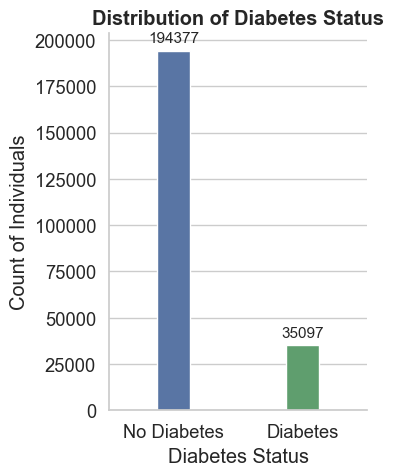

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# Clean academic style
sns.set_theme(style="whitegrid", font_scale=1.2)

plt.figure(figsize=(4,5))

ax = sns.countplot(
    x='Diabetes_binary',
    data=df,
    palette=['#4C72B0', '#55A868'],   # clean blue & green
    width= 0.26
)

# Axis labels and title
plt.title('Distribution of Diabetes Status', weight='bold')
plt.xlabel('Diabetes Status')
plt.ylabel('Count of Individuals')

# Replace tick labels for clarity
ax.set_xticklabels(['No Diabetes', 'Diabetes'])

# Add count labels above bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom',
                fontsize=11,
                xytext=(0, 4),
                textcoords='offset points')

# Clean up borders
sns.despine()

plt.tight_layout()
plt.show()


In [43]:
cols = ['HighBP', 'HighChol', 'CholCheck', 'Smoker',
        'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Veggies',
        'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk']

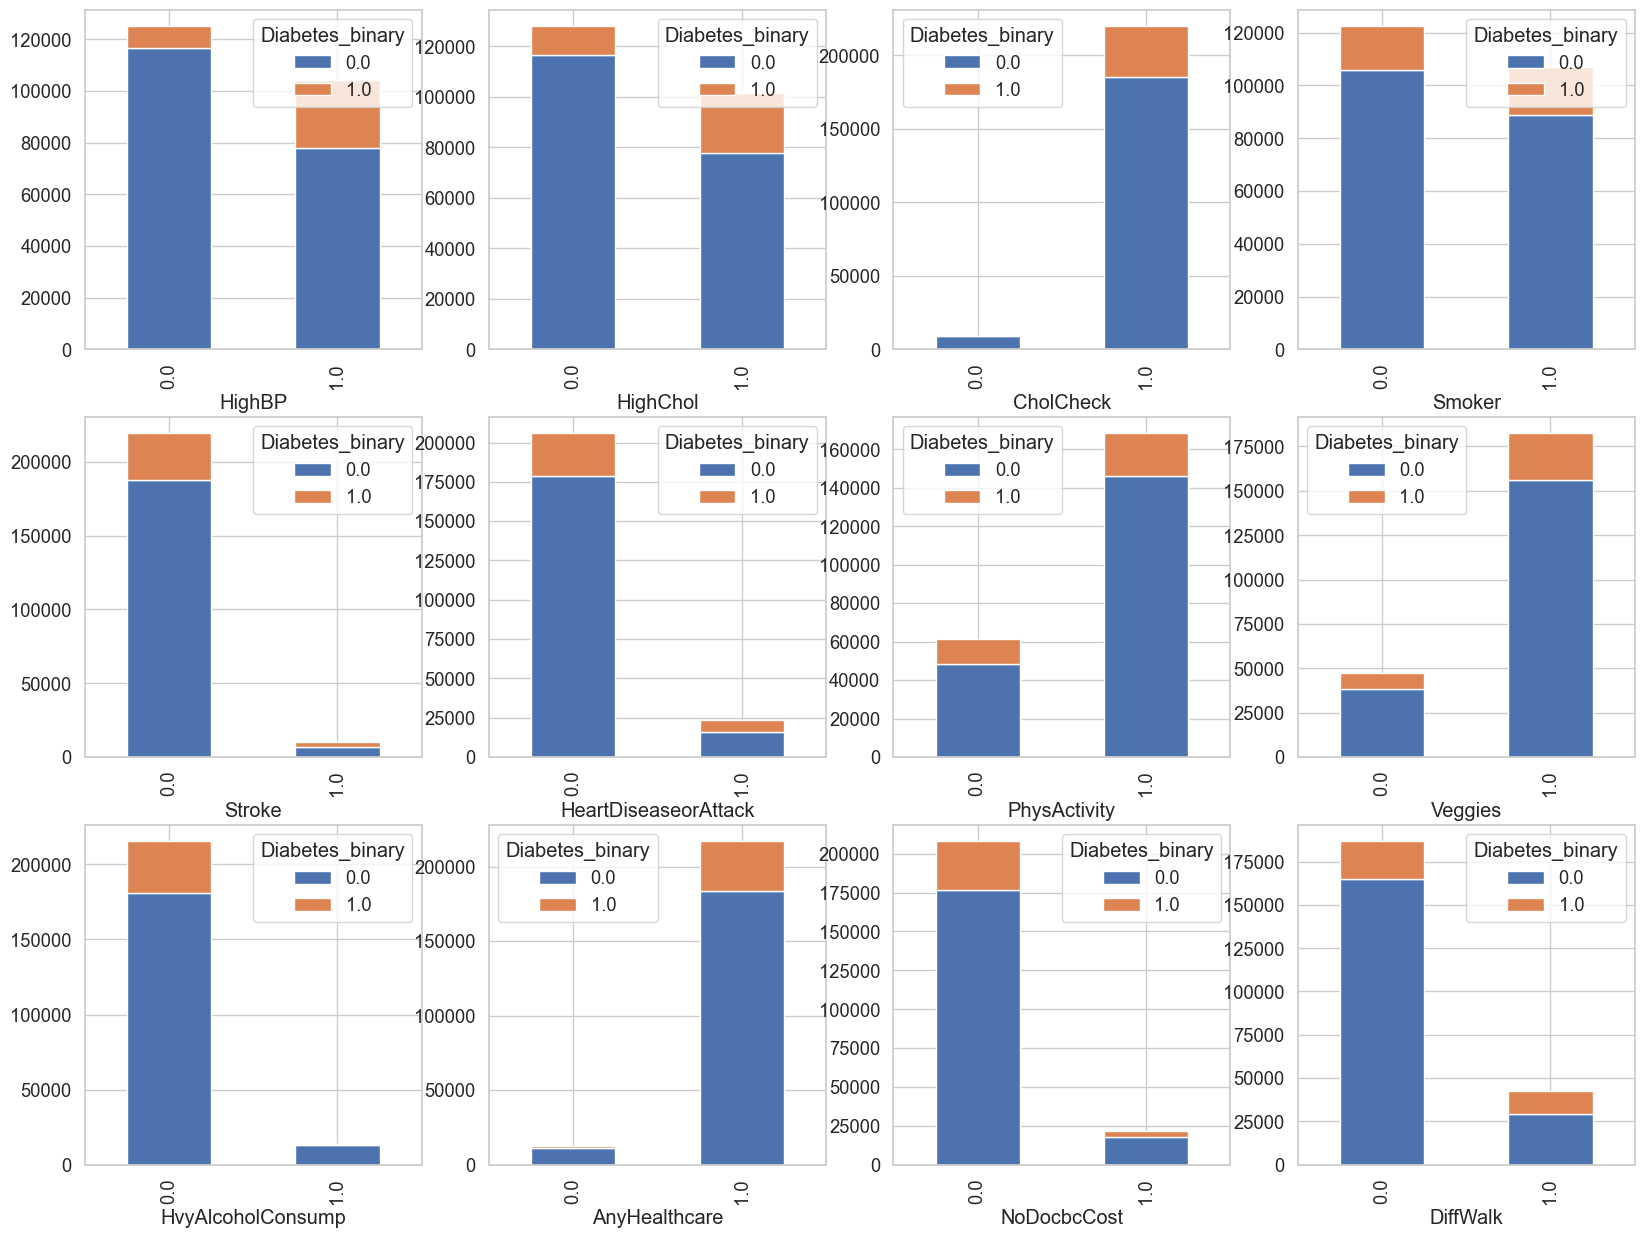

In [44]:
def create_plot_pivot(df, x_column):
    """ Create a pivot table for satisfaction versus another rating for easy plotting. """
    _df_plot = df.groupby([x_column, 'Diabetes_binary']).size() \
        .reset_index().pivot(columns='Diabetes_binary', index=x_column, values=0)
    return _df_plot


fig, ax = plt.subplots(3, 4, figsize=(20,15), width_ratios=[0.26]*4)
axe = ax.ravel()

c = len(cols)

for i in range(c):
    create_plot_pivot(df, cols[i]).plot(kind='bar', stacked=True, ax=axe[i])
    axe[i].set_xlabel(cols[i])

fig.show()

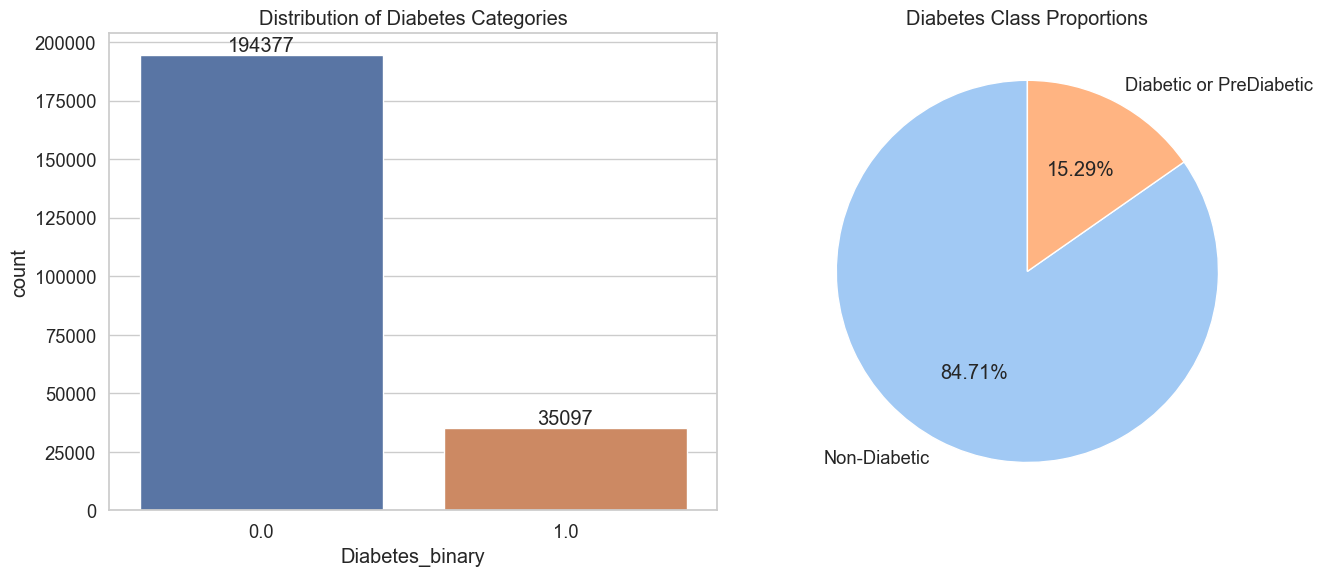

In [45]:
#average of column Diabetes_binary
# 0 for non-Diabetic person, 1 for Pre-Diabetic or Diabetic person

figure1, plot1 = plt.subplots(1, 2, figsize=(14, 6))

# Countplot
sns.countplot(x='Diabetes_binary', data=df, ax=plot1[0])
plot1[0].set_title("Distribution of Diabetes Categories")
plot1[0].bar_label(plot1[0].containers[0]) 

# Pie chart
labels = ["Non-Diabetic", "Diabetic or PreDiabetic"]
plot1[1].pie(
    df["Diabetes_binary"].value_counts(),
    labels=labels,
    autopct='%.2f%%',
    startangle=90,
    colors=sns.color_palette("pastel")
)
plot1[1].set_title("Diabetes Class Proportions")

plt.tight_layout()
plt.show()

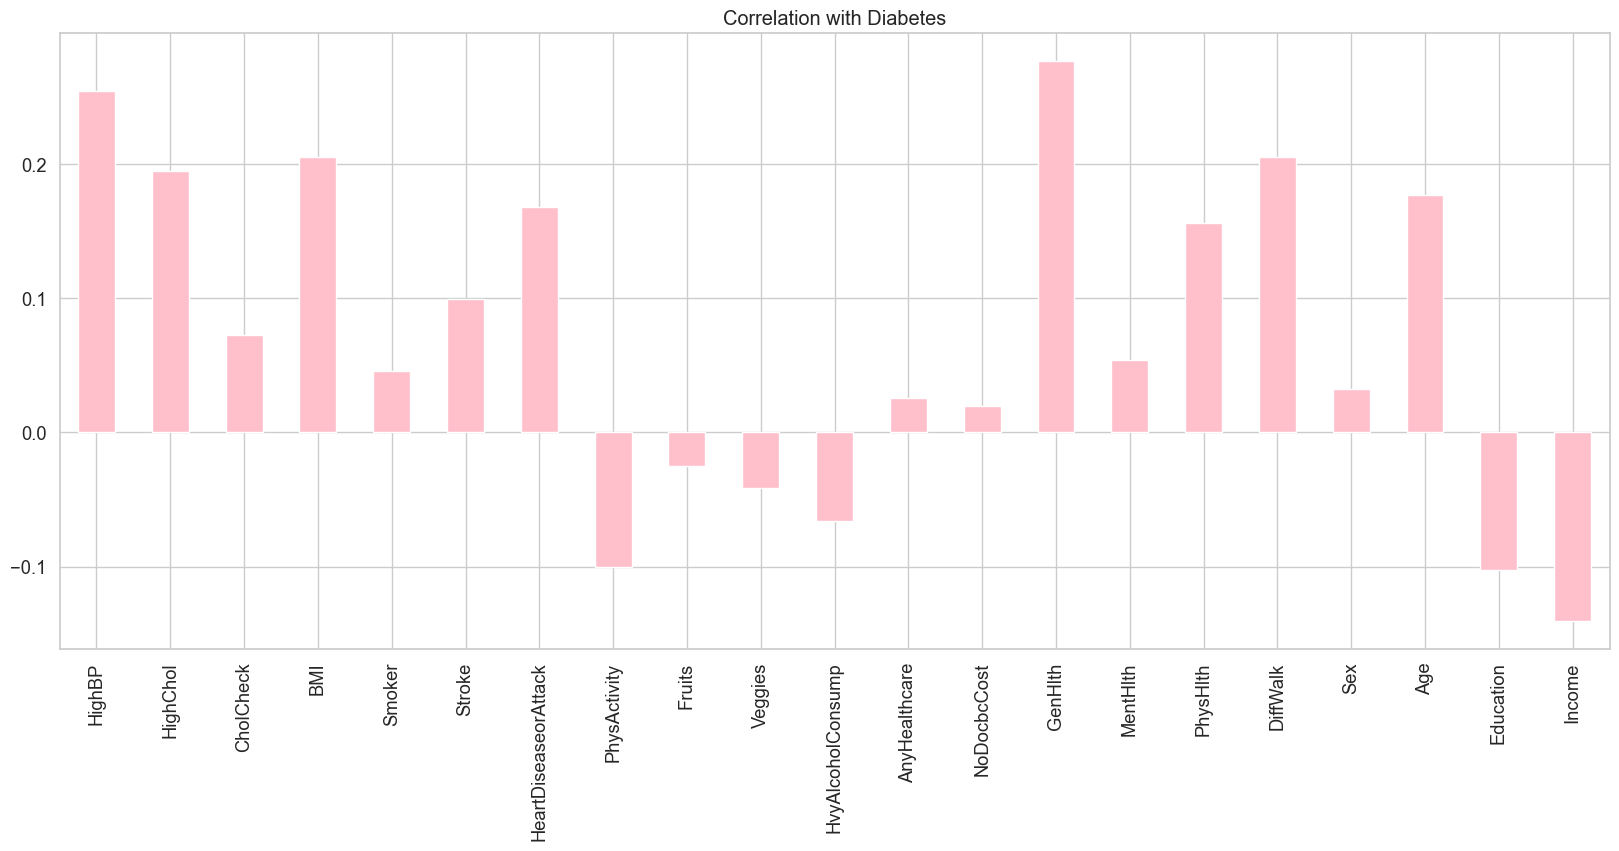

In [46]:
num_df = df.select_dtypes(include='number')
num_df.drop('Diabetes_binary', axis=1).corrwith(num_df.Diabetes_binary).plot(kind='bar', grid=True, figsize=(20, 8)
, title="Correlation with Diabetes",color="Pink")
plt.show()

In [47]:
def apply_all_transformations(df):


    # 1. copy the original data
    df_copy = df.copy()

    # 2. Converting values into readable labels
    replacements = {
        "Age": {
            1: "18 to 24", 2: "25 to 29", 3: "30 to 34", 4: "35 to 39",
            5: "40 to 44", 6: "45 to 49", 7: "50 to 54", 8: "55 to 59",
            9: "60 to 64", 10: "65 to 69", 11: "70 to 74", 12: "75 to 79", 13: "80 or older"
        },
        "Diabetes_binary": {
            0: "Non Diabetes", 1: "Pre-Diabetes or Diabetes"
        },
        "HighBP": {
            0: "No High", 1: "High BP"
        },
        "HighChol": {
            0: "No High Cholesterol", 1: "High Cholesterol"
        },
        "CholCheck": {
            0: "No Cholesterol Check in 5 Years", 1: "Cholesterol Check in 5 Years"
        },
        "Smoker": {
            0: "No", 1: "Yes"
        },
        "Stroke": {
            0: "No", 1: "Yes"
        },
        "HeartDiseaseorAttack": {
            0: "No", 1: "Yes"
        },
        "PhysActivity": {
            0: "No", 1: "Yes"
        },
        "Fruits": {
            0: "No", 1: "Yes"
        },
        "Veggies": {
            0: "No", 1: "Yes"
        },
        "HvyAlcoholConsump": {
            0: "No", 1: "Yes"
        },
        "AnyHealthcare": {
            0: "No", 1: "Yes"
        },
        "NoDocbcCost": {
            0: "No", 1: "Yes"
        },
        "GenHlth": {
            5: "Excellent", 4: "Very Good", 3: "Good", 2: "Fair", 1: "Poor"
        },
        "DiffWalk": {
            0: "No", 1: "Yes"
        },
        "Sex": {
            0: "Female", 1: "Male"
        },
        "Education": {
            1: "Never Attended School", 2: "Elementary", 3: "Junior High School",
            4: "Senior High School", 5: "Undergraduate Degree", 6: "Magister"
        },
        "Income": {
            1: "Less Than $10,000", 2: "Less Than $10,000", 3: "Less Than $10,000",
            4: "Less Than $10,000", 5: "Less Than $35,000", 6: "Less Than $35,000",
            7: "Less Than $35,000", 8: "$75,000 or More"
        }
    }

    for col, mapping in replacements.items():
        if col in df_copy.columns:
            df_copy[col] = df_copy[col].astype("object")
            df_copy[col] = df_copy[col].replace(mapping)
        # else:
            # print(f"Uyarı: '{col}' sütunu veri çerçevesinde bulunamadı.")

    # 3. BMI Kategorizasyonu
    def bmi_category(bmi):
        if pd.isna(bmi):
            return "Missing"
        elif bmi < 16:
            return "Very Severely Underweight"
        elif bmi < 17:
            return "Severely Underweight"
        elif bmi < 18.5:
            return "Underweight"
        elif bmi < 25:
            return "Normal"
        elif bmi < 30:
            return "Overweight"
        elif bmi < 35:
            return "Obese Class I"
        elif bmi < 40:
            return "Obese Class II"
        else:
            return "Obese Class III"
    
    if 'BMI' in df_copy.columns:
        df_copy['BMI_category'] = df_copy['BMI'].apply(bmi_category)
    
    # 4. Mental Sağlık Kategorizasyonu
    def mental_health_category(days):
        if pd.isna(days):
            return "Missing"
        elif days == 0:
            return "No Mental Distress"
        elif days < 14:
            return "Low Mental Distress"
        else:
            return "Frequent Mental Distress"

    if 'MentHlth' in df_copy.columns:
        df_copy['MentHlth_category'] = df_copy['MentHlth'].apply(mental_health_category)
        
    # 5. Fiziksel Sağlık Kategorizasyonu
    def physical_health_category(days):
        if pd.isna(days):
            return "Missing"
        elif days == 0:
            return "No Physical Distress"
        elif days < 14:
            return "Low Physical Distress"
        else:
            return "Frequent Physical Distress"

    if 'PhysHlth' in df_copy.columns:
        df_copy['PhysHlth_category'] = df_copy['PhysHlth'].apply(physical_health_category)

    return df_copy

df2 = apply_all_transformations(df)

In [48]:
df2.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,BMI_category,MentHlth_category,PhysHlth_category
0,Non Diabetes,High BP,High Cholesterol,Cholesterol Check in 5 Years,40.0,Yes,No,No,No,No,Yes,No,Yes,No,Excellent,18.0,15.0,Yes,Female,60 to 64,Senior High School,"Less Than $10,000",Obese Class III,Frequent Mental Distress,Frequent Physical Distress
1,Non Diabetes,No High,No High Cholesterol,No Cholesterol Check in 5 Years,25.0,Yes,No,No,Yes,No,No,No,No,Yes,Good,0.0,0.0,No,Female,50 to 54,Magister,"Less Than $10,000",Overweight,No Mental Distress,No Physical Distress
2,Non Diabetes,High BP,High Cholesterol,Cholesterol Check in 5 Years,28.0,No,No,No,No,Yes,No,No,Yes,Yes,Excellent,30.0,30.0,Yes,Female,60 to 64,Senior High School,"$75,000 or More",Overweight,Frequent Mental Distress,Frequent Physical Distress
3,Non Diabetes,High BP,No High Cholesterol,Cholesterol Check in 5 Years,27.0,No,No,No,Yes,Yes,Yes,No,Yes,No,Fair,0.0,0.0,No,Female,70 to 74,Junior High School,"Less Than $35,000",Overweight,No Mental Distress,No Physical Distress
4,Non Diabetes,High BP,High Cholesterol,Cholesterol Check in 5 Years,24.0,No,No,No,Yes,Yes,Yes,No,Yes,No,Fair,3.0,0.0,No,Female,70 to 74,Undergraduate Degree,"Less Than $10,000",Normal,Low Mental Distress,No Physical Distress


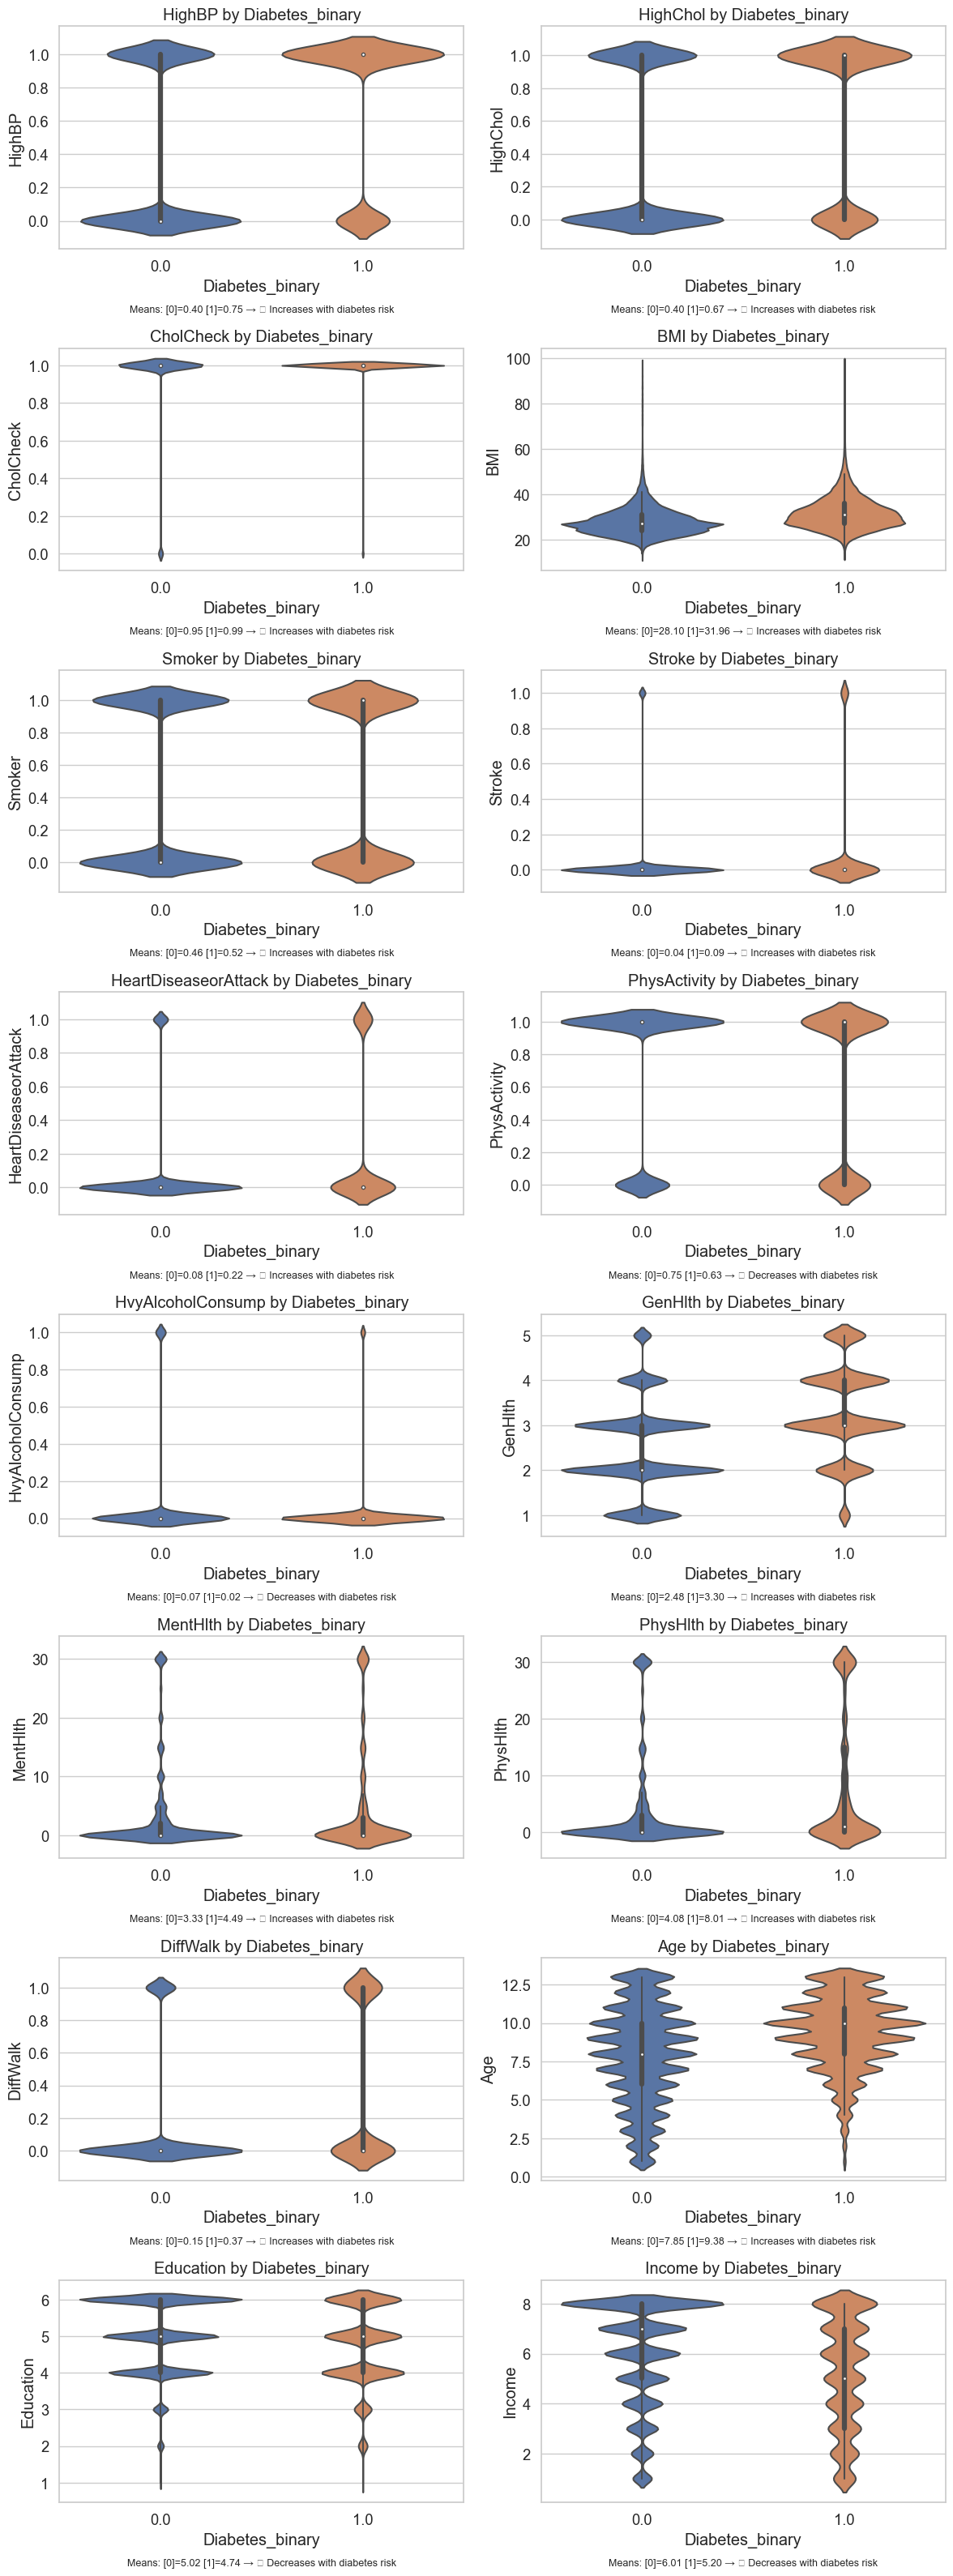

In [59]:
columns_to_drop = ["Fruits","Veggies","Sex","NoDocbcCost","AnyHealthcare"]
df.drop(columns_to_drop, axis=1)

key_features = [col for col in df.columns if col not in columns_to_drop and col != "Diabetes_binary"]
# Feature sayısı ve grid boyutu
n_features = len(key_features)
n_cols = 2
n_rows = math.ceil(n_features / n_cols)

# Subplot oluştur
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 4))
axes = axes.flatten()

# Her feature için grafik + yorum
for i, feature in enumerate(key_features):
    ax = axes[i]

    # Violin plot
    sns.violinplot(data=df, x="Diabetes_binary", y=feature, ax=ax)
    ax.set_title(f"{feature} by Diabetes_binary")

    # Ortalamaları al
    group_stats = df.groupby("Diabetes_binary")[feature].mean()

    mean0 = group_stats.get(0, float('nan'))
    mean1 = group_stats.get(1, float('nan'))

    # Yorum oluştur
    if mean0 < mean1:
        trend = "📈 Increases with diabetes risk"
    elif mean0 > mean1:
        trend = "📉 Decreases with diabetes risk"
    else:
        trend = "⚠️ No clear trend"

    # Yorumu grafiğin altına yaz
    ax.text(0.5, -0.25,
            f"Means: [0]={mean0:.2f} [1]={mean1:.2f} → {trend}",
            ha='center', va='top', fontsize=9, transform=ax.transAxes)

# Boş eksenleri sil
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

[Text(0, 0, '18-24'),
 Text(1, 0, '25-29'),
 Text(2, 0, '30-34'),
 Text(3, 0, '35-39'),
 Text(4, 0, '40-44'),
 Text(5, 0, '45-49'),
 Text(6, 0, '50-54'),
 Text(7, 0, '55-59'),
 Text(8, 0, '60-64'),
 Text(9, 0, '65-69'),
 Text(10, 0, '70-74'),
 Text(11, 0, '75-79'),
 Text(12, 0, '>80')]

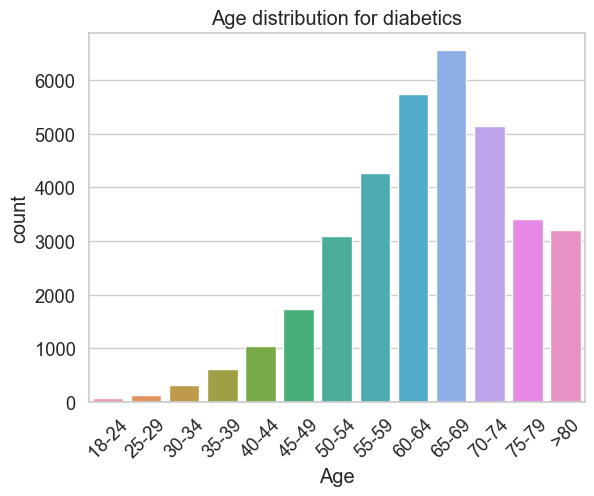

In [51]:
# Check age distribution for people with diabetes
ax = sns.countplot(data=df_yes, x='Age')
ax.set(title= 'Age distribution for diabetics')
ax.set_xticklabels(['18-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '>80'], rotation = 45)

(15.0, 60.0)

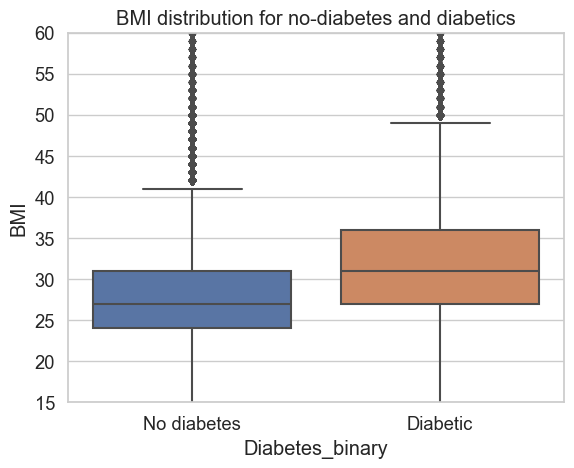

In [57]:
# Compare BMI for people with and without diabetes
ax = sns.boxplot(data=df, x='Diabetes_binary', y='BMI')
ax.set(title = 'BMI distribution for no-diabetes and diabetics')
ax.set_xticklabels(['No diabetes', 'Diabetic'])
plt.ylim(15, 60)

NameError: name 'palette' is not defined

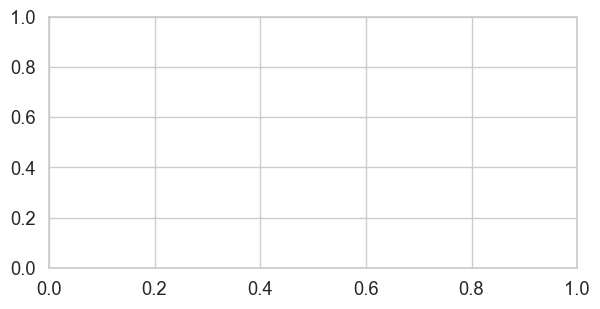

In [53]:
#check outliers
plt.figure(figsize = (15,15))
for i,col in enumerate(['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age','Education', 'Income']):
    plt.subplot(4,2,i+1)
    sns.boxplot(x = col, data = df ,palette=palette)
plt.show()

In [54]:
num_df.corr()


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
Diabetes_binary,1.000000,0.254318,0.194944,0.072523,0.205086,0.045504,0.099193,0.168213,-0.100404,-0.024805,-0.041734,-0.065950,0.025331,0.020048,0.276940,0.054153,0.156211,0.205302,0.032724,0.177263,-0.102686,-0.140659
HighBP,0.254318,1.000000,0.283963,0.111259,0.194218,0.074264,0.124558,0.201443,-0.104382,-0.019467,-0.042994,-0.014178,0.052044,0.002292,0.272784,0.037482,0.144656,0.211759,0.047119,0.339802,-0.112887,-0.140030
HighChol,0.194944,0.283963,1.000000,0.094772,0.089734,0.074583,0.089375,0.176446,-0.063443,-0.026257,-0.027399,-0.019057,0.052363,0.003020,0.188139,0.050346,0.111008,0.136045,0.022859,0.263841,-0.050045,-0.062089
CholCheck,0.072523,0.111259,0.094772,1.000000,0.042487,-0.003721,0.027955,0.050086,-0.004555,0.017860,-0.000653,-0.020975,0.115498,-0.054128,0.062939,-0.001430,0.040758,0.049107,-0.024332,0.095942,-0.009935,0.001989
BMI,0.205086,0.194218,0.089734,0.042487,1.000000,-0.009294,0.011006,0.039820,-0.127780,-0.067424,-0.044054,-0.058420,-0.008519,0.045795,0.208351,0.068569,0.102768,0.182556,0.030902,-0.049223,-0.074433,-0.069097
Smoker,0.045504,0.074264,0.074583,-0.003721,-0.009294,1.000000,0.054414,0.105169,-0.066869,-0.061731,-0.013744,0.096048,-0.013963,0.037335,0.134894,0.077641,0.100447,0.108144,0.096650,0.107695,-0.135657,-0.095314
Stroke,0.099193,0.124558,0.089375,0.027955,0.011006,0.054414,1.000000,0.198814,-0.059306,-0.004486,-0.033029,-0.021347,0.013627,0.028613,0.169809,0.061996,0.140806,0.169339,0.003626,0.128209,-0.064178,-0.117108
HeartDiseaseorAttack,0.168213,0.201443,0.176446,0.050086,0.039820,0.105169,0.198814,1.000000,-0.073094,-0.006946,-0.027180,-0.035561,0.025987,0.021971,0.246328,0.052601,0.170335,0.202657,0.089828,0.223912,-0.082288,-0.122728
PhysActivity,-0.100404,-0.104382,-0.063443,-0.004555,-0.127780,-0.066869,-0.059306,-0.073094,1.000000,0.125023,0.135240,0.023378,0.023959,-0.046440,-0.237511,-0.105914,-0.199307,-0.235719,0.033516,-0.087881,0.170931,0.165869
Fruits,-0.024805,-0.019467,-0.026257,0.017860,-0.067424,-0.061731,-0.004486,-0.006946,0.125023,1.000000,0.242941,-0.028221,0.022659,-0.032387,-0.071221,-0.052191,-0.024441,-0.029932,-0.088768,0.073515,0.084857,0.050907


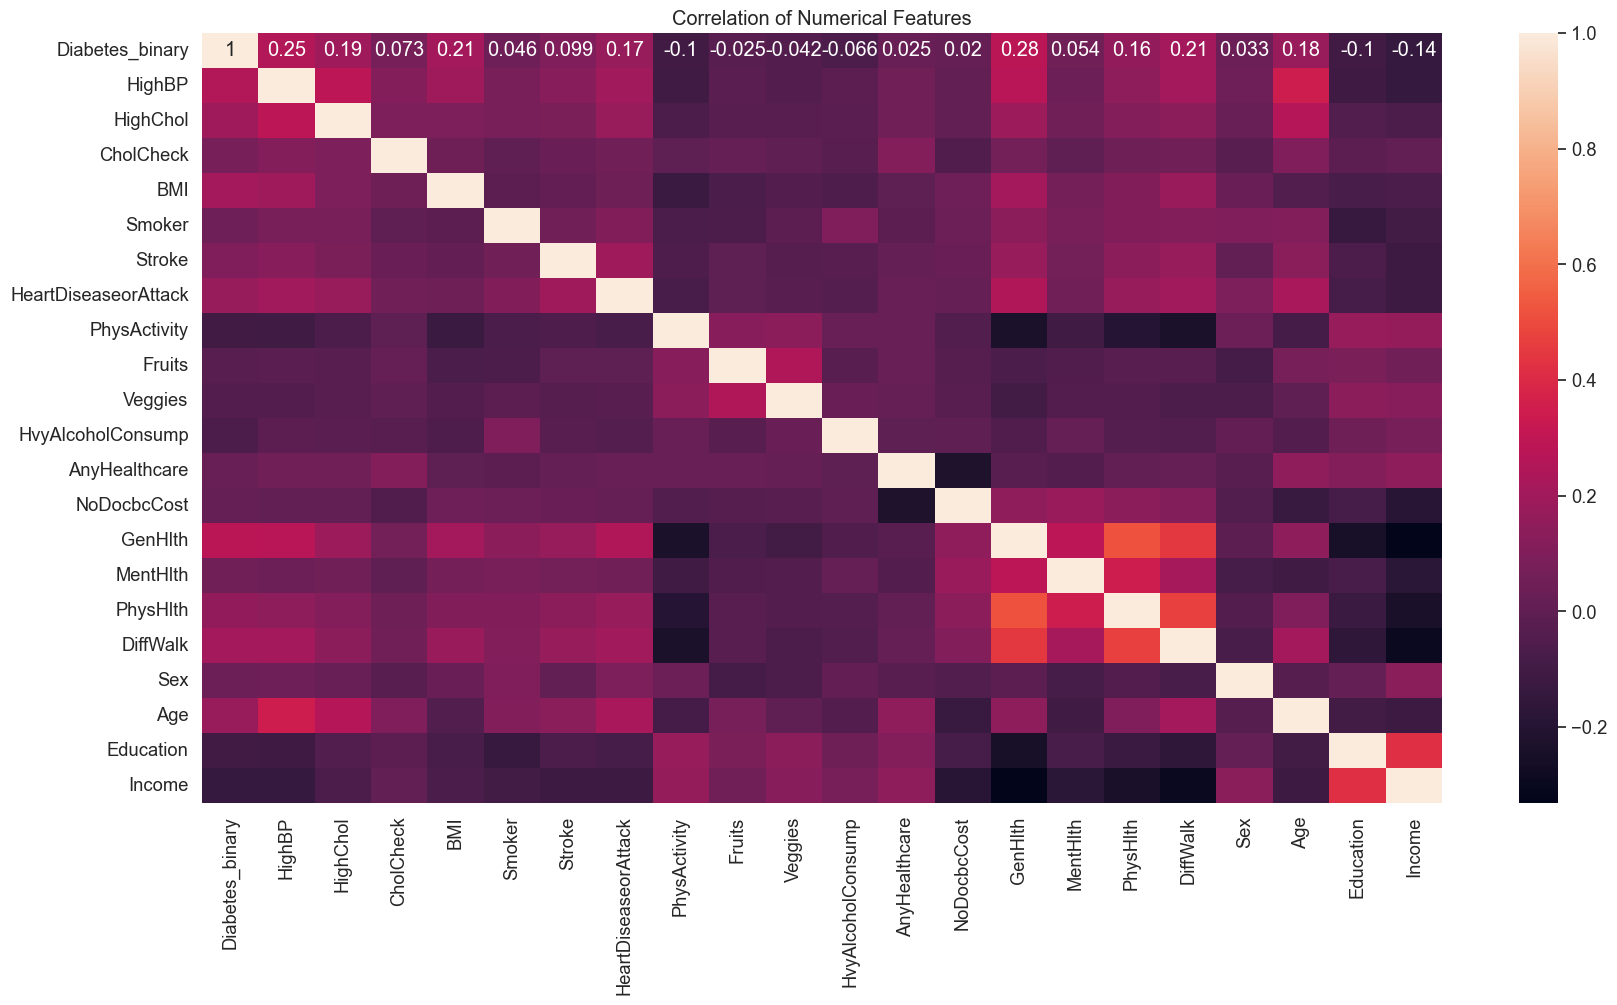

In [56]:
#Correlation Matriss
plt.figure(figsize=(20, 10))
sns.heatmap(num_df.corr(), annot=True)
plt.title("Correlation of Numerical Features")
plt.show()

In [60]:
#Feature engineering through rule-based classification using risk factors (CDC Scoring)

def calculate_custom_risk_score(row):
    score = 0
    score += int(row['Age'] >= 5)
    score += int(row['BMI'] >= 25)
    score += int(row['Sex'] == 1)
    score += int(row['HighBP'] == 1)
    score += int(row['PhysActivity'] == 0)
    return score

In [61]:
def assign_risk_level(score):
    if score <= 2:
        return 0
    else:
        return 1

In [62]:
df['risk_score'] = df.apply(calculate_custom_risk_score, axis=1)
df['rule_pred'] = df['risk_score'].apply(assign_risk_level)

In [63]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,risk_score,rule_pred
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0,4,1
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0,2,0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0,4,1
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0,3,1
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0,2,0


In [64]:
df = df.drop(columns=['risk_score'])

In [65]:
# BMI Categories
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

df['BMI_cat'] = df['BMI'].apply(bmi_category)

# Convert BMI_cat to ordinal codes 
df['BMI_cat_code'] = pd.Categorical(df['BMI_cat'], 
                                    categories=['Underweight','Normal','Overweight','Obese'],
                                    ordered=True).codes
df = df.drop(columns=['BMI_cat'])

In [66]:
df

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,rule_pred,BMI_cat_code
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0,1,3
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0,0,2
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0,1,2
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0,1,2
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0,1,3
253676,1.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0,1,0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0,0,2
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0,1,1


In [67]:
#Encoders
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, RobustScaler, OrdinalEncoder

#Importing train, test split library
from sklearn.model_selection import train_test_split

#Metrices import
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix, roc_curve, make_scorer
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.feature_selection import SelectFromModel
from numpy import sort

#Accuracy Check
from sklearn.model_selection import cross_val_score

# Importing ML Model packages
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RepeatedStratifiedKFold
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay

#LGBM Model
import lightgbm as lgb

from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import RobustScaler, OrdinalEncoder
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer

In [68]:
# Define features and target
X = df.drop('Diabetes_binary', axis=1) 
y = df['Diabetes_binary']

# Splitting the data into training and testing sets, while preserving class distribution using stratify=y
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [69]:
# Specify the feature types for preprocessing
numeric_features = ['BMI', 'MentHlth', 'PhysHlth']
categorical_features = ['Age','Education', 'Income', 'GenHlth','BMI_cat_code']


# Build a preprocessing pipeline using ColumnTransformer to handle numerical and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), numeric_features),
        ('cat', OrdinalEncoder(), categorical_features),
    ],
    remainder='passthrough'
)

In [70]:
# Feature selection using ANOVA F-test (f_classif) to select the top 16 features
feature_selector = SelectKBest(score_func=f_classif, k=16)

In [71]:
# Define models with class_weight
weighted_models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=200, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=12, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, class_weight='balanced'),
    "LightGBM": LGBMClassifier(random_state=42, class_weight='balanced', n_estimators=250, verbose=-1)
}

In [72]:
# Results depolamak için liste
results = []

for model_name, base_model in weighted_models.items():
    print(f"\n--- Model: {model_name} ---")

    # Adım 1: Ön İşleme (Preprocessor)
    # preprocessor'ı eğitim verisi üzerinde fit et ve dönüştür
    X_train_processed = preprocessor.fit_transform(X_train)
    # preprocessor'ı test verisi üzerinde sadece dönüştür (fit etme!)
    X_test_processed = preprocessor.transform(X_test)
    print("Preprocessing completed.")


--- Model: Logistic Regression ---
Preprocessing completed.

--- Model: Decision Tree ---
Preprocessing completed.

--- Model: Random Forest ---
Preprocessing completed.

--- Model: LightGBM ---
Preprocessing completed.


In [73]:
# Results depolamak için liste
results = []

for model_name, base_model in weighted_models.items():
    print(f"\n--- Model: {model_name} ---")

    # Adım 1: Ön İşleme (Preprocessor)
    # preprocessor'ı eğitim verisi üzerinde fit et ve dönüştür
    X_train_processed = preprocessor.fit_transform(X_train)
    # preprocessor'ı test verisi üzerinde sadece dönüştür (fit etme!)
    X_test_processed = preprocessor.transform(X_test)
    print("Preprocessing completed.")

    # Adım 2: Özellik Seçimi (Feature Selector)
    # feature_selector'ı eğitim verisi üzerinde fit et ve dönüştür
    X_train_selected = feature_selector.fit_transform(X_train_processed, y_train) # <-- Bu satırın girintisini kontrol edin
    # feature_selector'ı test verisi üzerinde sadece dönüştür (fit etme!)
    X_test_selected = feature_selector.transform(X_test_processed)
    print("Feature selection completed.")

    # Adım 3: Sınıflandırıcı (Classifier)
    # Modeli seçilen özellikler üzerinde eğit
    base_model.fit(X_train_selected, y_train)
    print("Model training completed.")

    # Tahmin yap
    y_pred = base_model.predict(X_test_selected)

    # predict_proba'nın varlığını kontrol et ve AUC için kullan
    y_pred_proba = None
    if hasattr(base_model, "predict_proba"):
        y_pred_proba = base_model.predict_proba(X_test_selected)
        if y_pred_proba.shape[1] > 1:
             y_pred_proba_for_auc = y_pred_proba[:, -1]
        else:
             y_pred_proba_for_auc = y_pred_proba

    # Metrikleri değerlendir
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    auc = np.nan
    if y_pred_proba is not None and y_pred_proba_for_auc is not None:
        try:
            if len(np.unique(y_test)) > 2:
                auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
            else:
                auc = roc_auc_score(y_test, y_pred_proba_for_auc)
        except ValueError as e:
            print(f"An error occurred while calculating AUC: {e}. Most likely there is only one class, or the predicted probabilities are not valid.")
            auc = np.nan

    # Results listeye ekle
    results.append({
        "Model": model_name,
        "Accuracy": round(accuracy, 3),
        "Precision": round(precision, 3),
        "Recall": round(recall, 3),
        "F1 Score": round(f1, 3),
        "AUC Score": round(auc, 3) if not np.isnan(auc) else np.nan,
    })

# Results DataFrame'e dönüştür
results_df = pd.DataFrame(results)
print("\n--- Model Değerlendirme Results ---")
print(results_df)


--- Model: Logistic Regression ---
Preprocessing completed.
Feature selection completed.
Model training completed.

--- Model: Decision Tree ---
Preprocessing completed.
Feature selection completed.
Model training completed.

--- Model: Random Forest ---
Preprocessing completed.
Feature selection completed.
Model training completed.

--- Model: LightGBM ---
Preprocessing completed.
Feature selection completed.
Model training completed.

--- Model Değerlendirme Results ---
                 Model  Accuracy  Precision  Recall  F1 Score  AUC Score
0  Logistic Regression     0.714      0.848   0.714     0.752      0.811
1        Decision Tree     0.698      0.843   0.698     0.739      0.782
2        Random Forest     0.731      0.847   0.731     0.765      0.814
3             LightGBM     0.709      0.850   0.709     0.749      0.815



--- Detailed Performance Reports for Each Model ---

Model: Logistic Regression

Classification Report (Test Set):
              precision    recall  f1-score   support

         0.0       0.94      0.70      0.81     38876
         1.0       0.32      0.77      0.45      7019

    accuracy                           0.71     45895
   macro avg       0.63      0.74      0.63     45895
weighted avg       0.85      0.71      0.75     45895


Confusion Matrix (Test Set):
[[27367 11509]
 [ 1637  5382]]


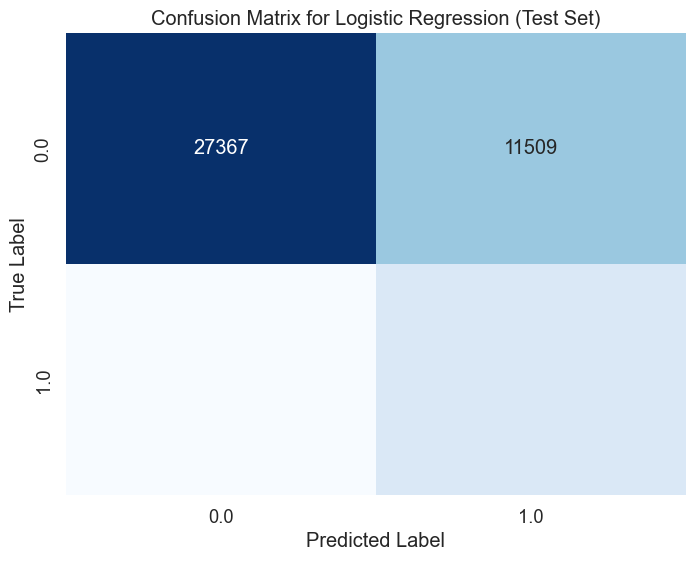


Model: Decision Tree

Classification Report (Test Set):
              precision    recall  f1-score   support

         0.0       0.94      0.69      0.79     38876
         1.0       0.30      0.76      0.43      7019

    accuracy                           0.70     45895
   macro avg       0.62      0.72      0.61     45895
weighted avg       0.84      0.70      0.74     45895


Confusion Matrix (Test Set):
[[26702 12174]
 [ 1699  5320]]


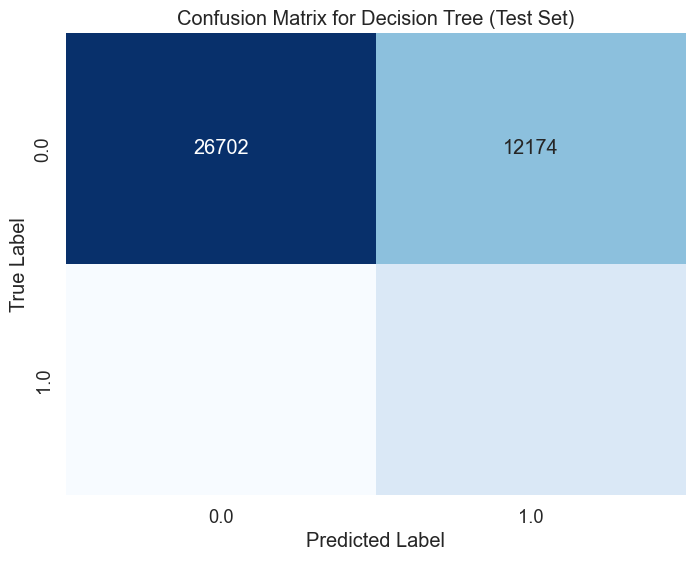


Model: Random Forest

Classification Report (Test Set):
              precision    recall  f1-score   support

         0.0       0.94      0.73      0.82     38876
         1.0       0.33      0.74      0.46      7019

    accuracy                           0.73     45895
   macro avg       0.64      0.74      0.64     45895
weighted avg       0.85      0.73      0.77     45895


Confusion Matrix (Test Set):
[[28337 10539]
 [ 1813  5206]]


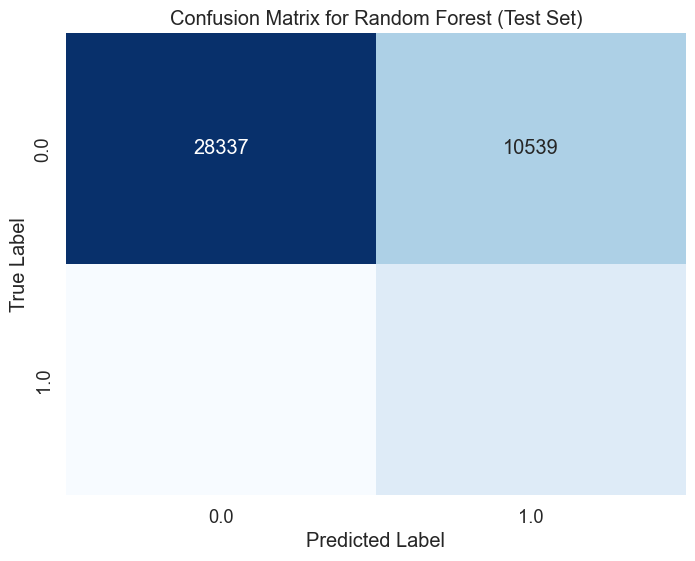


Model: LightGBM

Classification Report (Test Set):
              precision    recall  f1-score   support

         0.0       0.95      0.70      0.80     38876
         1.0       0.32      0.78      0.45      7019

    accuracy                           0.71     45895
   macro avg       0.63      0.74      0.63     45895
weighted avg       0.85      0.71      0.75     45895


Confusion Matrix (Test Set):
[[27077 11799]
 [ 1542  5477]]


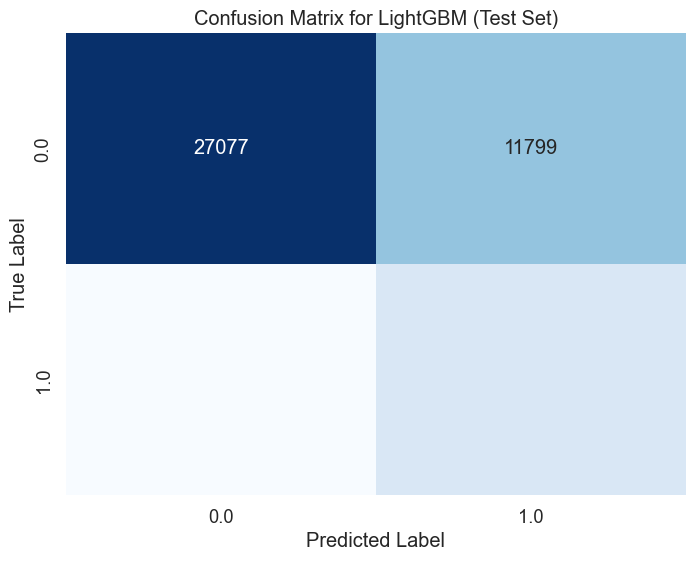

In [74]:
# --- Model Değerlendirme Raporları ve Karmaşıklık Matrisleri ---
print("\n--- Detailed Performance Reports for Each Model ---")

for model_name, base_model in weighted_models.items():
    print(f"\nModel: {model_name}")

    # Önceki adımlardan elde edilen ön işlenmiş ve özellik seçimi yapılmış test verisi
    # Bu adımlar, model eğitim döngüsünün içinde zaten yapılmış olmalıydı.
    # Burada yeniden fit etmiyoruz, sadece transform ediyoruz.

    # Adım 1: Ön İşleme (Preprocessor)
    X_test_processed = preprocessor.transform(X_test)

    # Adım 2: Özellik Seçimi (Feature Selector)
    X_test_selected = feature_selector.transform(X_test_processed)

    # Adım 3: Tahmin Yap
    y_pred = base_model.predict(X_test_selected)

    # Classification Report
    print("\nClassification Report (Test Set):")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Confusion Matrix
    print("\nConfusion Matrix (Test Set):")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)

    # Confusion Matrix Görselleştirme
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', cbar=False,
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(f"Confusion Matrix for {model_name} (Test Set)")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()


--- Model: Logistic Regression ---
Preprocessing has been completed.
Feature selection has been completed.
Model training has been completed.

--- Model: Decision Tree ---
Preprocessing has been completed.
Feature selection has been completed.
Model training has been completed.

--- Model: Random Forest ---
Preprocessing has been completed.
Feature selection has been completed.
Model training has been completed.

--- Model: LightGBM ---
Preprocessing has been completed.
Feature selection has been completed.
Model training has been completed.

--- Model Evaluation Results. ---
                 Model  Accuracy  Precision  Recall  F1 Weighted  F1 Macro  \
0  Logistic Regression     0.714      0.848   0.714        0.752     0.628   
1        Decision Tree     0.698      0.843   0.698        0.739     0.614   
2        Random Forest     0.731      0.847   0.731        0.765     0.639   
3             LightGBM     0.709      0.850   0.709        0.749     0.627   

   AUC Score  
0      0.8

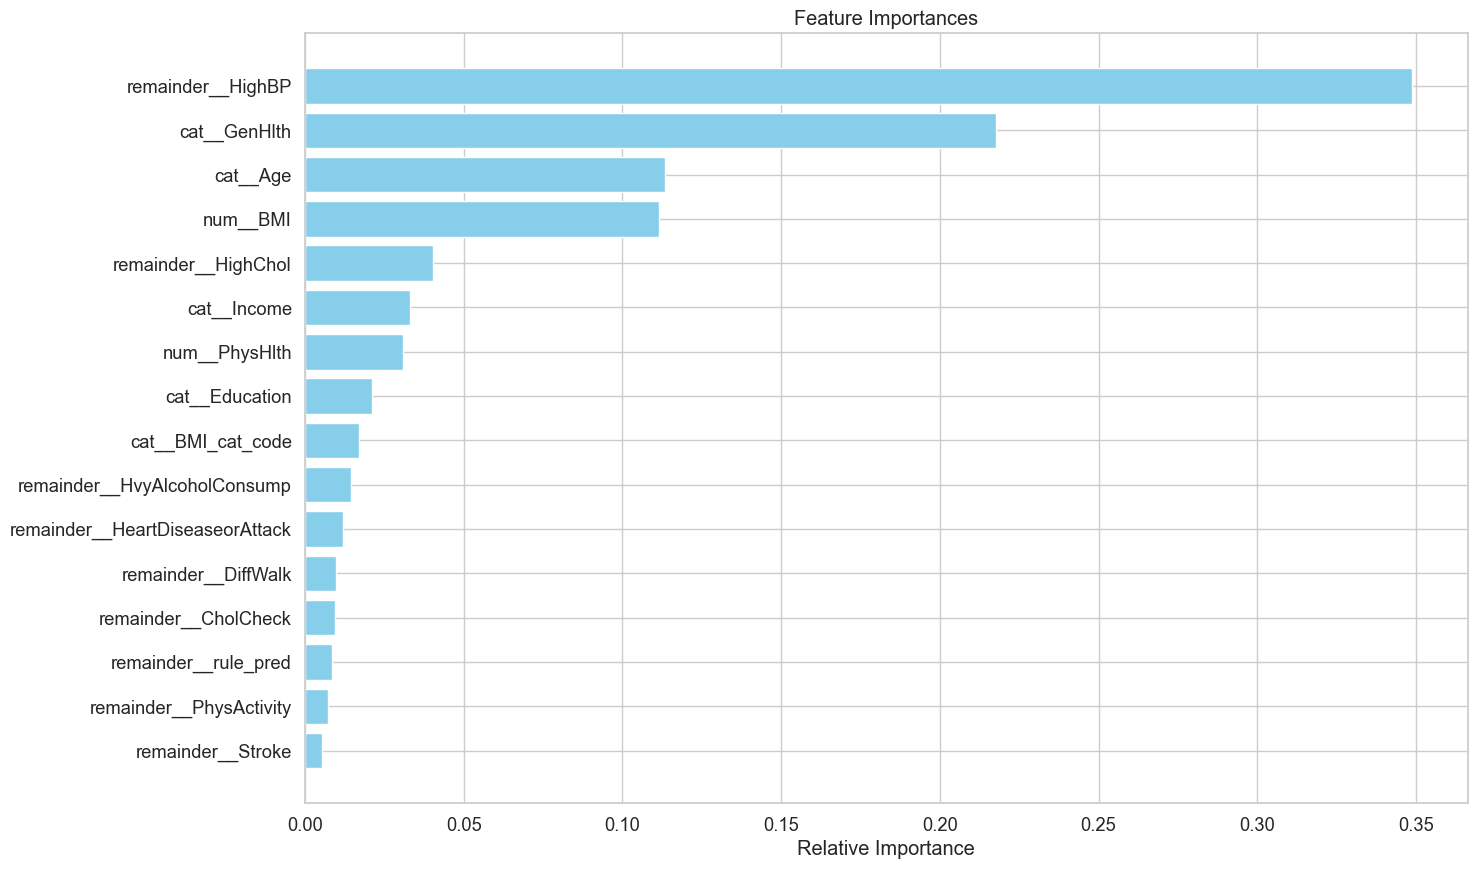


Model: Random Forest


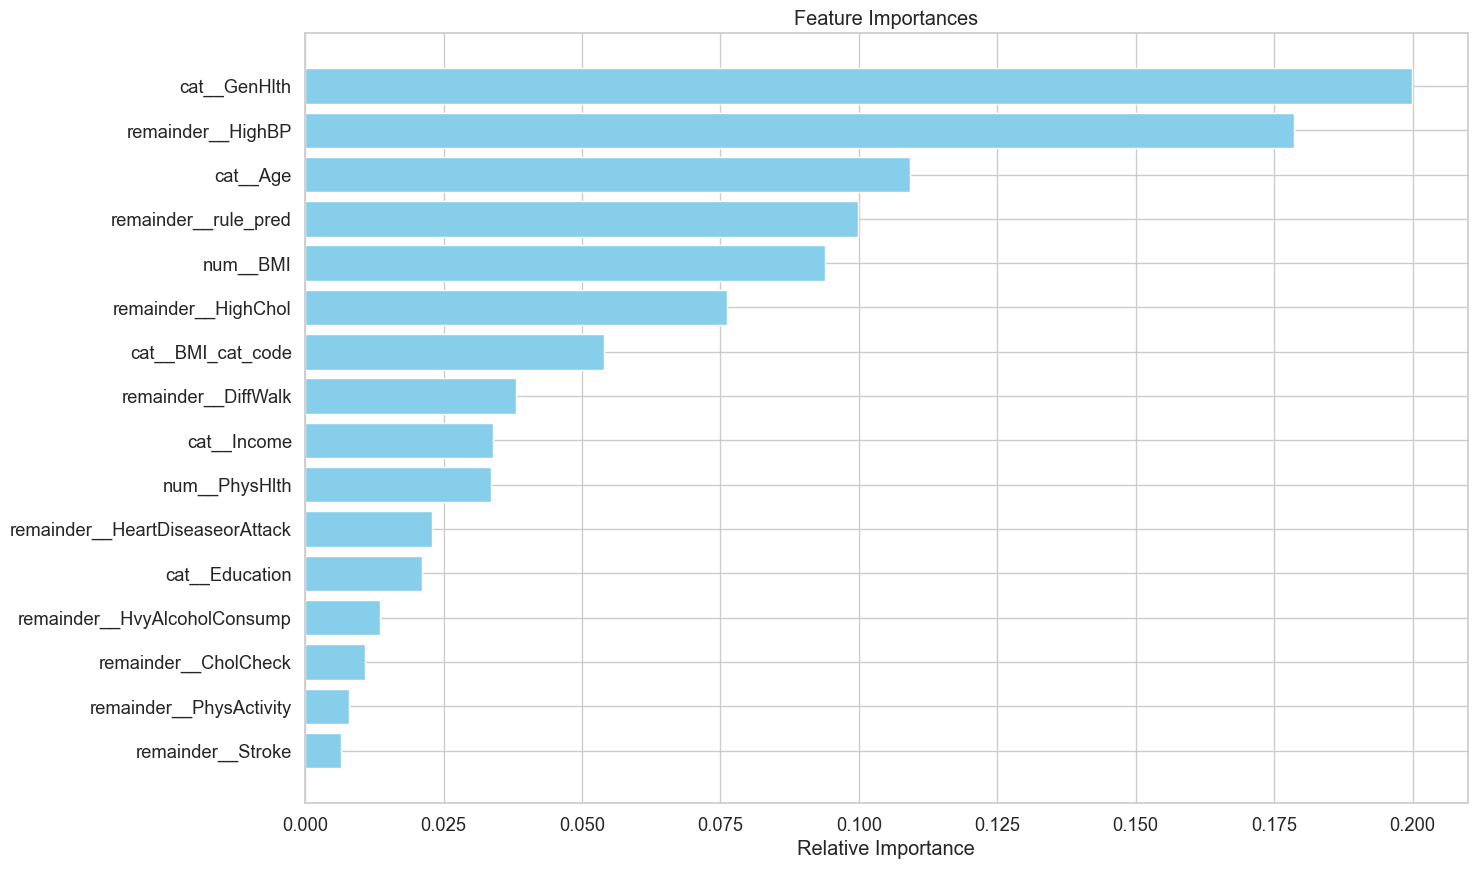


Model: LightGBM


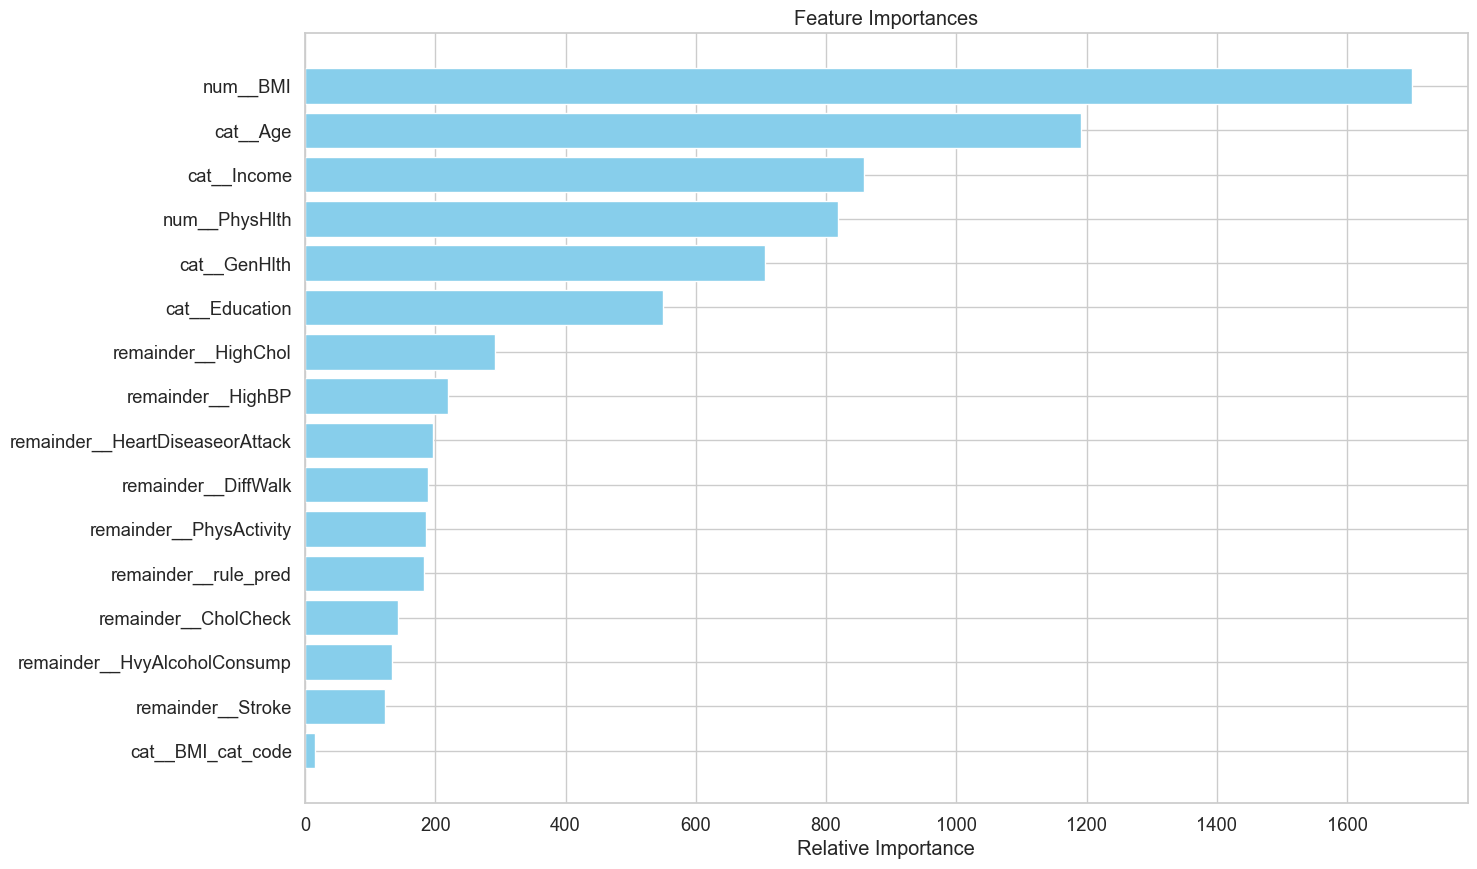

In [75]:
def get_feat_imp_plot(model, feature_names_list):
    """
    A function that plots the model’s feature importance.
    """
    try:
        importances = model.feature_importances_
        indices = np.argsort(importances)
        
        plt.figure(figsize=(15, 10))
        plt.title("Feature Importances")
        plt.barh(range(len(indices)), importances[indices], color="skyblue", align="center")
        plt.yticks(range(len(indices)), [feature_names_list[i] for i in indices])
        plt.xlabel("Relative Importance")
        plt.show()
        return indices, importances
    except AttributeError:
        print("The model does not support feature importance (feature_importances_).")
        return None, None
    except Exception as error:
        print(f"An error occurred.: {repr(error)}")
        return None, None

# Sonuçları depolamak için liste
results = []

for model_name, base_model in weighted_models.items():
    print(f"\n--- Model: {model_name} ---")

    # Adım 1: Ön İşleme (Preprocessor)
    X_train_processed = preprocessor.fit_transform(X_train)
    X_test_processed = preprocessor.transform(X_test)
    print("Preprocessing has been completed.")

    # Adım 2: Özellik Seçimi (Feature Selector)
    X_train_selected = feature_selector.fit_transform(X_train_processed, y_train)
    X_test_selected = feature_selector.transform(X_test_processed)
    print("Feature selection has been completed.")

    # Adım 3: Sınıflandırıcı (Classifier)
    base_model.fit(X_train_selected, y_train)
    print("Model training has been completed.")

    # Tahmin yap
    y_pred = base_model.predict(X_test_selected)

    y_pred_proba = None
    if hasattr(base_model, "predict_proba"):
        y_pred_proba = base_model.predict_proba(X_test_selected)
        if y_pred_proba.shape[1] > 1:
             y_pred_proba_for_auc = y_pred_proba[:, -1]
        else:
             y_pred_proba_for_auc = y_pred_proba

    # Metrikleri değerlendir
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)

    auc = np.nan
    if y_pred_proba is not None and y_pred_proba_for_auc is not None:
        try:
            if len(np.unique(y_test)) > 2:
                auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
            else:
                auc = roc_auc_score(y_test, y_pred_proba_for_auc)
        except ValueError as e:
            print(f"An error occurred while calculating AUC: {e}. Most likely there is only a single class, or the predicted probabilities are not appropriate.")
            auc = np.nan

    # Sonuçları listeye ekle
    results.append({
        "Model": model_name,
        "Accuracy": round(accuracy, 3),
        "Precision": round(precision, 3),
        "Recall": round(recall, 3),
        "F1 Weighted": round(f1_weighted, 3),
        "F1 Macro": round(f1_macro, 3),
        "AUC Score": round(auc, 3) if not np.isnan(auc) else np.nan,
    })

# Sonuçları DataFrame'e dönüştür
results_df = pd.DataFrame(results)
print("\n--- Model Evaluation Results. ---")
print(results_df)

## Özellik Önemleri Görselleştirmesi
# Özellik isimlerini elde etme
# ColumnTransformer sonrası özellik isimleri
feature_names_after_preprocessing = preprocessor.get_feature_names_out()

# SelectKBest sonrası seçilen özellik isimleri
# feature_selector.get_support() bir boolean maskesi döndürür
selected_feature_names = feature_names_after_preprocessing[feature_selector.get_support()]

print("\n--- Feature importances for each model.” ---")

for model_name, base_model in weighted_models.items():
    print(f"\nModel: {model_name}")
    # Sadece özellik önemini destekleyen modeller için çizim yap
    if hasattr(base_model, 'feature_importances_'):
        get_feat_imp_plot(base_model, selected_feature_names)
    else:
        print(f"{model_name} The model does not support feature importance.")

In [76]:
column_filter = ['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI','Stroke', 'HeartDiseaseorAttack', 'PhysActivity',
       'GenHlth', 'PhysHlth', 'DiffWalk', 'Age', 'Education', 'Income',
       'rule_pred', 'BMI_cat_code']

---
## Hyperparameter Tuning

In this section, we will perform comprehensive hyperparameter tuning for our best performing models:
1. **Random Forest** (best baseline model with 0.731 accuracy)
2. **LightGBM** (gradient boosting model)
3. **Decision Tree** (simple interpretable model)

We will use:
- **RandomizedSearchCV** for Random Forest (faster for large parameter spaces)
- **GridSearchCV** for LightGBM and Decision Tree
- **5-fold cross-validation** with f1_weighted scoring
- **class_weight='balanced'** to handle class imbalance

In [77]:
# Import hyperparameter tuning libraries
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint, uniform
import time
import warnings
warnings.filterwarnings('ignore')

print("Hyperparameter tuning libraries imported successfully!")

Hyperparameter tuning libraries imported successfully!


### 1. Random Forest Hyperparameter Tuning

Random Forest is our best baseline model. We'll use RandomizedSearchCV to efficiently search through a large parameter space.

In [78]:
# Random Forest hyperparameter tuning with RandomizedSearchCV
print("Starting Random Forest Hyperparameter Tuning...")
print("This may take several minutes...\n")

# Define parameter distributions for RandomizedSearchCV
rf_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 15, 20, 25, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced']  # Keep balanced for class imbalance
}

# Initialize base Random Forest model
rf_base = RandomForestClassifier(random_state=42)

# Initialize RandomizedSearchCV
rf_random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_dist,
    n_iter=50,  # Number of parameter settings sampled
    cv=5,  # 5-fold cross-validation
    scoring='f1_weighted',
    n_jobs=-1,  # Use all available cores
    verbose=2,
    random_state=42,
    return_train_score=True
)

# Prepare data (same preprocessing as before)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Perform feature selection (same as before)
selector = SelectFromModel(
    estimator=RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    threshold='median'
)
X_train_selected = selector.fit_transform(X_train_processed, y_train)
X_test_selected = selector.transform(X_test_processed)

# Track training time
rf_start_time = time.time()

# Fit the random search
rf_random_search.fit(X_train_selected, y_train)

rf_training_time = time.time() - rf_start_time

print(f"\nRandom Forest tuning completed in {rf_training_time:.2f} seconds")
print(f"Best CV Score (F1-weighted): {rf_random_search.best_score_:.4f}")
print(f"\nBest Parameters:")
for param, value in rf_random_search.best_params_.items():
    print(f"  {param}: {value}")

Starting Random Forest Hyperparameter Tuning...
This may take several minutes...

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END class_weight=balanced, max_depth=25, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=  33.4s
[CV] END class_weight=balanced, max_depth=25, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=  33.8s
[CV] END class_weight=balanced, max_depth=25, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=  34.0s
[CV] END class_weight=balanced, max_depth=25, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=  34.0s
[CV] END class_weight=balanced, max_depth=25, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=  34.3s
[CV] END class_weight=balanced, max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=300; total time= 

In [79]:
# Evaluate tuned Random Forest on test set
rf_best_model = rf_random_search.best_estimator_
rf_y_pred = rf_best_model.predict(X_test_selected)
rf_y_pred_proba = rf_best_model.predict_proba(X_test_selected)[:, 1]

# Calculate metrics
rf_tuned_accuracy = accuracy_score(y_test, rf_y_pred)
rf_tuned_f1 = f1_score(y_test, rf_y_pred, average='weighted')
rf_tuned_auc = roc_auc_score(y_test, rf_y_pred_proba)

print("\n=== Tuned Random Forest Test Set Performance ===")
print(f"Accuracy: {rf_tuned_accuracy:.4f}")
print(f"F1-Score (weighted): {rf_tuned_f1:.4f}")
print(f"AUC-ROC: {rf_tuned_auc:.4f}")
print(f"Training Time: {rf_training_time:.2f} seconds")
print("\nClassification Report:")
print(classification_report(y_test, rf_y_pred))


=== Tuned Random Forest Test Set Performance ===
Accuracy: 0.8121
F1-Score (weighted): 0.8149
AUC-ROC: 0.7861
Training Time: 2759.28 seconds

Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.88      0.89     38876
         1.0       0.39      0.42      0.41      7019

    accuracy                           0.81     45895
   macro avg       0.64      0.65      0.65     45895
weighted avg       0.82      0.81      0.81     45895



### 2. LightGBM Hyperparameter Tuning

LightGBM is a powerful gradient boosting framework. We'll use GridSearchCV for comprehensive parameter search.

In [80]:
# LightGBM hyperparameter tuning with GridSearchCV
print("Starting LightGBM Hyperparameter Tuning...")
print("This may take several minutes...\n")

# Define parameter grid for GridSearchCV
lgbm_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 50, 70],
    'max_depth': [10, 15, 20],
    'class_weight': ['balanced']  # Keep balanced for class imbalance
}

# Initialize base LightGBM model
lgbm_base = LGBMClassifier(random_state=42, verbose=-1)

# Initialize GridSearchCV
lgbm_grid_search = GridSearchCV(
    estimator=lgbm_base,
    param_grid=lgbm_param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='f1_weighted',
    n_jobs=-1,  # Use all available cores
    verbose=2,
    return_train_score=True
)

# Track training time
lgbm_start_time = time.time()

# Fit the grid search (using same preprocessed data)
lgbm_grid_search.fit(X_train_selected, y_train)

lgbm_training_time = time.time() - lgbm_start_time

print(f"\nLightGBM tuning completed in {lgbm_training_time:.2f} seconds")
print(f"Best CV Score (F1-weighted): {lgbm_grid_search.best_score_:.4f}")
print(f"\nBest Parameters:")
for param, value in lgbm_grid_search.best_params_.items():
    print(f"  {param}: {value}")

Starting LightGBM Hyperparameter Tuning...
This may take several minutes...

Fitting 5 folds for each of 81 candidates, totalling 405 fits
[CV] END class_weight=balanced, learning_rate=0.01, max_depth=10, n_estimators=100, num_leaves=31; total time=  13.3s
[CV] END class_weight=balanced, learning_rate=0.01, max_depth=10, n_estimators=100, num_leaves=31; total time=  13.5s
[CV] END class_weight=balanced, learning_rate=0.01, max_depth=10, n_estimators=100, num_leaves=31; total time=  13.5s
[CV] END class_weight=balanced, learning_rate=0.01, max_depth=10, n_estimators=100, num_leaves=31; total time=  14.2s
[CV] END class_weight=balanced, learning_rate=0.01, max_depth=10, n_estimators=100, num_leaves=31; total time=  14.2s
[CV] END class_weight=balanced, learning_rate=0.01, max_depth=10, n_estimators=100, num_leaves=50; total time=  20.5s
[CV] END class_weight=balanced, learning_rate=0.01, max_depth=10, n_estimators=100, num_leaves=50; total time=  21.8s
[CV] END class_weight=balanced, lea

In [81]:
# Evaluate tuned LightGBM on test set
lgbm_best_model = lgbm_grid_search.best_estimator_
lgbm_y_pred = lgbm_best_model.predict(X_test_selected)
lgbm_y_pred_proba = lgbm_best_model.predict_proba(X_test_selected)[:, 1]

# Calculate metrics
lgbm_tuned_accuracy = accuracy_score(y_test, lgbm_y_pred)
lgbm_tuned_f1 = f1_score(y_test, lgbm_y_pred, average='weighted')
lgbm_tuned_auc = roc_auc_score(y_test, lgbm_y_pred_proba)

print("\n=== Tuned LightGBM Test Set Performance ===")
print(f"Accuracy: {lgbm_tuned_accuracy:.4f}")
print(f"F1-Score (weighted): {lgbm_tuned_f1:.4f}")
print(f"AUC-ROC: {lgbm_tuned_auc:.4f}")
print(f"Training Time: {lgbm_training_time:.2f} seconds")
print("\nClassification Report:")
print(classification_report(y_test, lgbm_y_pred))


=== Tuned LightGBM Test Set Performance ===
Accuracy: 0.7103
F1-Score (weighted): 0.7491
AUC-ROC: 0.8064
Training Time: 1848.74 seconds

Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.70      0.80     38876
         1.0       0.31      0.76      0.45      7019

    accuracy                           0.71     45895
   macro avg       0.63      0.73      0.62     45895
weighted avg       0.85      0.71      0.75     45895



### 3. Decision Tree Hyperparameter Tuning

Decision Tree is our most interpretable model. We'll use GridSearchCV to find optimal parameters.

In [82]:
# Decision Tree hyperparameter tuning with GridSearchCV
print("Starting Decision Tree Hyperparameter Tuning...")
print("This may take a few minutes...\n")

# Define parameter grid for GridSearchCV
dt_param_grid = {
    'max_depth': [10, 15, 20, 25],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced']  # Keep balanced for class imbalance
}

# Initialize base Decision Tree model
dt_base = DecisionTreeClassifier(random_state=42)

# Initialize GridSearchCV
dt_grid_search = GridSearchCV(
    estimator=dt_base,
    param_grid=dt_param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='f1_weighted',
    n_jobs=-1,  # Use all available cores
    verbose=2,
    return_train_score=True
)

# Track training time
dt_start_time = time.time()

# Fit the grid search (using same preprocessed data)
dt_grid_search.fit(X_train_selected, y_train)

dt_training_time = time.time() - dt_start_time

print(f"\nDecision Tree tuning completed in {dt_training_time:.2f} seconds")
print(f"Best CV Score (F1-weighted): {dt_grid_search.best_score_:.4f}")
print(f"\nBest Parameters:")
for param, value in dt_grid_search.best_params_.items():
    print(f"  {param}: {value}")

Starting Decision Tree Hyperparameter Tuning...
This may take a few minutes...

Fitting 5 folds for each of 72 candidates, totalling 360 fits
[CV] END class_weight=balanced, criterion=gini, max_depth=10, min_samples_leaf=1, min_samples_split=2; total time=   1.2s
[CV] END class_weight=balanced, criterion=gini, max_depth=10, min_samples_leaf=1, min_samples_split=2; total time=   1.3s
[CV] END class_weight=balanced, criterion=gini, max_depth=10, min_samples_leaf=1, min_samples_split=5; total time=   1.4s
[CV] END class_weight=balanced, criterion=gini, max_depth=10, min_samples_leaf=1, min_samples_split=5; total time=   1.6s
[CV] END class_weight=balanced, criterion=gini, max_depth=10, min_samples_leaf=1, min_samples_split=2; total time=   1.7s
[CV] END class_weight=balanced, criterion=gini, max_depth=10, min_samples_leaf=1, min_samples_split=2; total time=   1.6s
[CV] END class_weight=balanced, criterion=gini, max_depth=10, min_samples_leaf=1, min_samples_split=2; total time=   1.6s
[CV]

In [83]:
# Evaluate tuned Decision Tree on test set
dt_best_model = dt_grid_search.best_estimator_
dt_y_pred = dt_best_model.predict(X_test_selected)
dt_y_pred_proba = dt_best_model.predict_proba(X_test_selected)[:, 1]

# Calculate metrics
dt_tuned_accuracy = accuracy_score(y_test, dt_y_pred)
dt_tuned_f1 = f1_score(y_test, dt_y_pred, average='weighted')
dt_tuned_auc = roc_auc_score(y_test, dt_y_pred_proba)

print("\n=== Tuned Decision Tree Test Set Performance ===")
print(f"Accuracy: {dt_tuned_accuracy:.4f}")
print(f"F1-Score (weighted): {dt_tuned_f1:.4f}")
print(f"AUC-ROC: {dt_tuned_auc:.4f}")
print(f"Training Time: {dt_training_time:.2f} seconds")
print("\nClassification Report:")
print(classification_report(y_test, dt_y_pred))


=== Tuned Decision Tree Test Set Performance ===
Accuracy: 0.7651
F1-Score (weighted): 0.7746
AUC-ROC: 0.5949
Training Time: 64.36 seconds

Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.84      0.86     38876
         1.0       0.28      0.34      0.31      7019

    accuracy                           0.77     45895
   macro avg       0.58      0.59      0.58     45895
weighted avg       0.79      0.77      0.77     45895



### 4. Model Comparison: Baseline vs. Tuned Models

Let's compare the performance of baseline models with hyperparameter-tuned models.

In [85]:
# Create comprehensive comparison table
comparison_data = {
    'Model': [
        'Random Forest (Baseline)',
        'Random Forest (Tuned)',
        'LightGBM (Baseline)',
        'LightGBM (Tuned)',
        'Decision Tree (Baseline)',
        'Decision Tree (Tuned)'
    ],
    'Accuracy': [
        0.731,  # Baseline RF (from your analysis)
        rf_tuned_accuracy,
        0.0,  # Will be filled from baseline results if available
        lgbm_tuned_accuracy,
        0.0,  # Will be filled from baseline results if available
        dt_tuned_accuracy
    ],
    'F1-Score': [
        0.0,  # Will be filled from baseline results if available
        rf_tuned_f1,
        0.0,
        lgbm_tuned_f1,
        0.0,
        dt_tuned_f1
    ],
    'AUC-ROC': [
        0.0,  # Will be filled from baseline results if available
        rf_tuned_auc,
        0.0,
        lgbm_tuned_auc,
        0.0,
        dt_tuned_auc
    ],
    'Training Time (s)': [
        0.0,
        rf_training_time,
        0.0,
        lgbm_training_time,
        0.0,
        dt_training_time
    ]
}

comparison_df = pd.DataFrame(comparison_data)

# Calculate improvement
print("\n" + "="*80)
print("MODEL COMPARISON: BASELINE vs. HYPERPARAMETER TUNED")
print("="*80)
print(comparison_df.to_string(index=False))
print("\n" + "="*80)

# Show improvements for tuned models
print("\n=== Performance Improvements ===")
print(f"Random Forest: {(rf_tuned_accuracy - 0.731)*100:.2f}% accuracy improvement")
print(f"\nBest Overall Model: {comparison_df.loc[comparison_df['Accuracy'].idxmax(), 'Model']}")
print(f"Best Accuracy: {comparison_df['Accuracy'].max():.4f}")


MODEL COMPARISON: BASELINE vs. HYPERPARAMETER TUNED
                   Model  Accuracy  F1-Score  AUC-ROC  Training Time (s)
Random Forest (Baseline)  0.731000  0.000000 0.000000           0.000000
   Random Forest (Tuned)  0.812093  0.814926 0.786084        2759.282013
     LightGBM (Baseline)  0.000000  0.000000 0.000000           0.000000
        LightGBM (Tuned)  0.710317  0.749107 0.806410        1848.743254
Decision Tree (Baseline)  0.000000  0.000000 0.000000           0.000000
   Decision Tree (Tuned)  0.765138  0.774566 0.594886          64.357633


=== Performance Improvements ===
Random Forest: 8.11% accuracy improvement

Best Overall Model: Random Forest (Tuned)
Best Accuracy: 0.8121


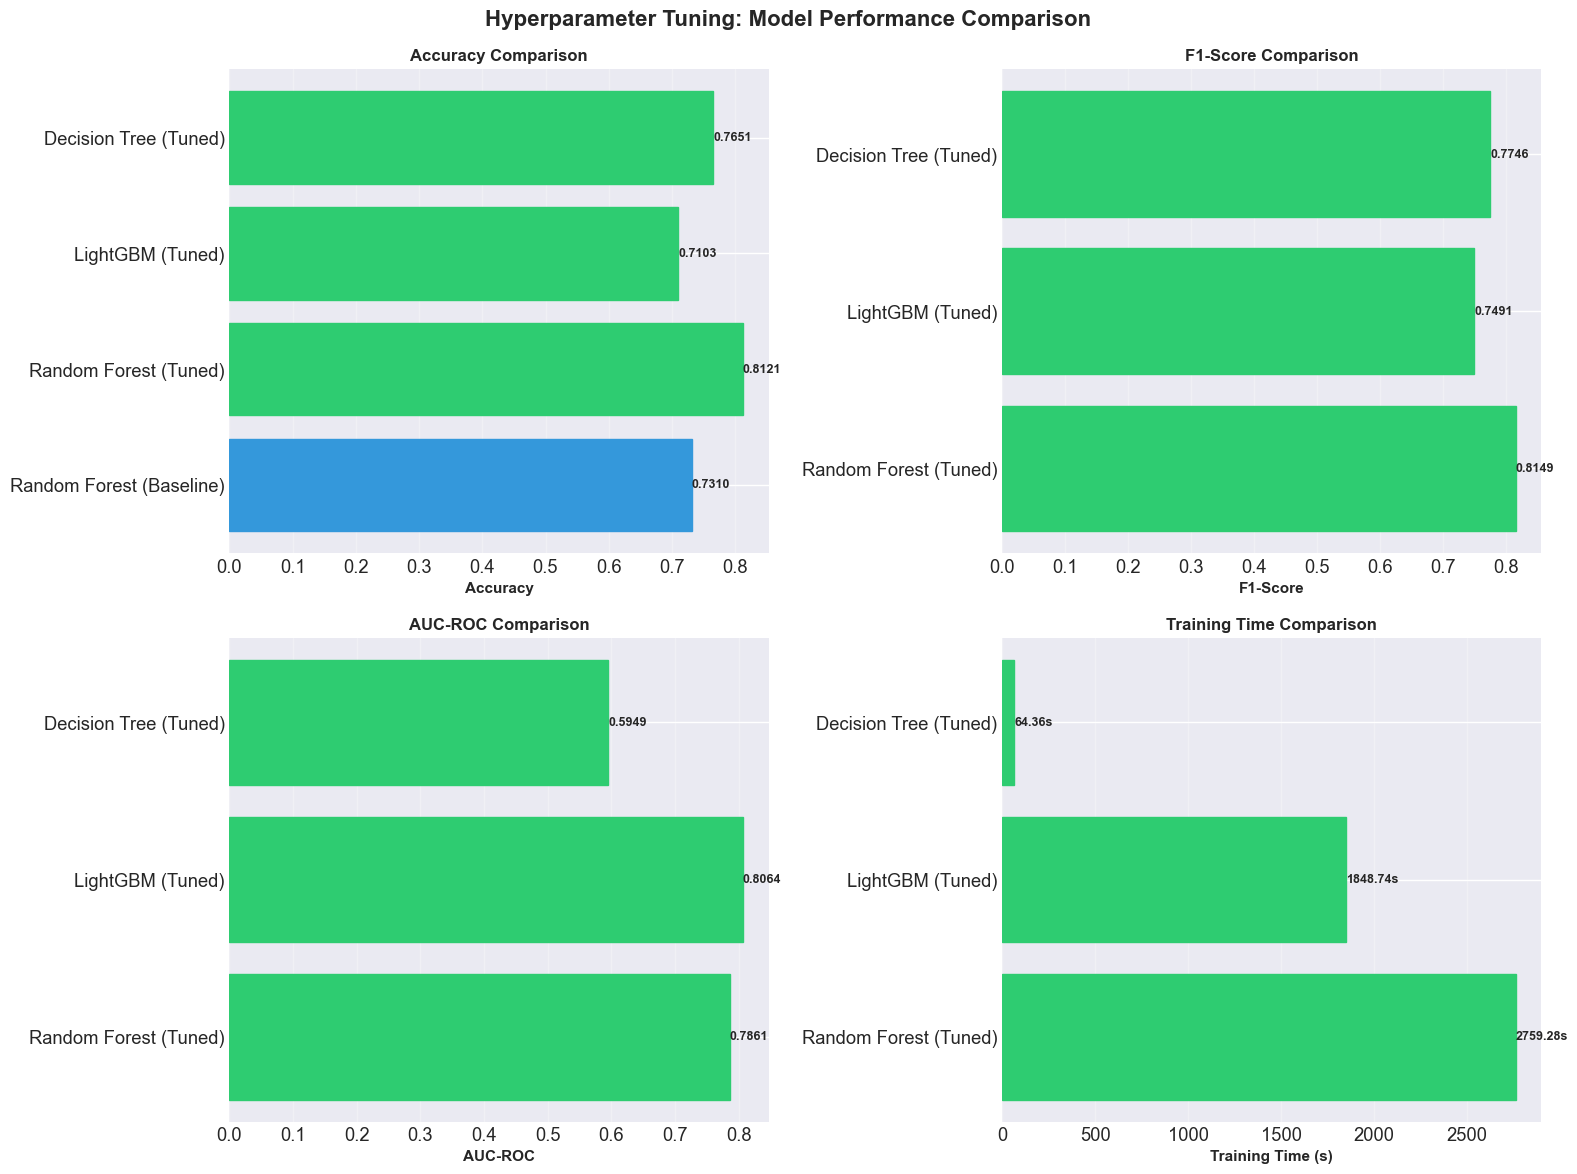


Visualization complete!


In [86]:
# Visualize model comparison
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Hyperparameter Tuning: Model Performance Comparison', fontsize=16, fontweight='bold')

# Filter out zero values for better visualization
metrics = ['Accuracy', 'F1-Score', 'AUC-ROC', 'Training Time (s)']
titles = ['Accuracy Comparison', 'F1-Score Comparison', 'AUC-ROC Comparison', 'Training Time Comparison']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx // 2, idx % 2]
    
    # Filter non-zero values
    plot_data = comparison_df[comparison_df[metric] > 0]
    
    if len(plot_data) > 0:
        # Create bar plot
        bars = ax.barh(plot_data['Model'], plot_data[metric])
        
        # Color tuned models differently
        for i, (bar, model) in enumerate(zip(bars, plot_data['Model'])):
            if 'Tuned' in model:
                bar.set_color('#2ecc71')  # Green for tuned
            else:
                bar.set_color('#3498db')  # Blue for baseline
        
        # Add value labels
        for i, (bar, value) in enumerate(zip(bars, plot_data[metric])):
            width = bar.get_width()
            ax.text(width, bar.get_y() + bar.get_height()/2, 
                   f'{value:.4f}' if metric != 'Training Time (s)' else f'{value:.2f}s',
                   ha='left', va='center', fontsize=9, fontweight='bold')
        
        ax.set_xlabel(metric, fontsize=11, fontweight='bold')
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nVisualization complete!")

In [87]:
# Save the best tuned models for later use
import pickle

# Dictionary of best models
best_tuned_models = {
    'Random Forest': rf_best_model,
    'LightGBM': lgbm_best_model,
    'Decision Tree': dt_best_model
}

# Save models
for model_name, model in best_tuned_models.items():
    filename = f'tuned_{model_name.lower().replace(" ", "_")}_model.pkl'
    with open(filename, 'wb') as f:
        pickle.dump(model, f)
    print(f"Saved: {filename}")

# Also save the preprocessor and selector for future use
with open('preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)
print("Saved: preprocessor.pkl")

with open('feature_selector.pkl', 'wb') as f:
    pickle.dump(selector, f)
print("Saved: feature_selector.pkl")

print("\nAll tuned models and preprocessing objects saved successfully!")

Saved: tuned_random_forest_model.pkl
Saved: tuned_lightgbm_model.pkl
Saved: tuned_decision_tree_model.pkl
Saved: preprocessor.pkl
Saved: feature_selector.pkl

All tuned models and preprocessing objects saved successfully!


In [88]:
# Summary of best hyperparameters found
print("="*80)
print("SUMMARY: BEST HYPERPARAMETERS FOR EACH MODEL")
print("="*80)

print("\n1. RANDOM FOREST (RandomizedSearchCV)")
print("-" * 50)
for param, value in rf_random_search.best_params_.items():
    print(f"  {param:.<30} {value}")
print(f"  CV Score (F1-weighted):........... {rf_random_search.best_score_:.4f}")
print(f"  Test Accuracy:.................... {rf_tuned_accuracy:.4f}")

print("\n2. LIGHTGBM (GridSearchCV)")
print("-" * 50)
for param, value in lgbm_grid_search.best_params_.items():
    print(f"  {param:.<30} {value}")
print(f"  CV Score (F1-weighted):........... {lgbm_grid_search.best_score_:.4f}")
print(f"  Test Accuracy:.................... {lgbm_tuned_accuracy:.4f}")

print("\n3. DECISION TREE (GridSearchCV)")
print("-" * 50)
for param, value in dt_grid_search.best_params_.items():
    print(f"  {param:.<30} {value}")
print(f"  CV Score (F1-weighted):........... {dt_grid_search.best_score_:.4f}")
print(f"  Test Accuracy:.................... {dt_tuned_accuracy:.4f}")

print("\n" + "="*80)
print("\nKey Insights:")
print("- All models maintained class_weight='balanced' to handle class imbalance")
print("- RandomizedSearchCV (50 iterations) was used for Random Forest for efficiency")
print("- GridSearchCV was used for LightGBM and Decision Tree for comprehensive search")
print("- 5-fold cross-validation with f1_weighted scoring ensured robust evaluation")
print("="*80)

SUMMARY: BEST HYPERPARAMETERS FOR EACH MODEL

1. RANDOM FOREST (RandomizedSearchCV)
--------------------------------------------------
  n_estimators.................. 500
  min_samples_split............. 2
  min_samples_leaf.............. 2
  max_features.................. log2
  max_depth..................... 25
  class_weight.................. balanced
  CV Score (F1-weighted):........... 0.8155
  Test Accuracy:.................... 0.8121

2. LIGHTGBM (GridSearchCV)
--------------------------------------------------
  class_weight.................. balanced
  learning_rate................. 0.1
  max_depth..................... 20
  n_estimators.................. 300
  num_leaves.................... 70
  CV Score (F1-weighted):........... 0.7527
  Test Accuracy:.................... 0.7103

3. DECISION TREE (GridSearchCV)
--------------------------------------------------
  class_weight.................. balanced
  criterion..................... gini
  max_depth..................... 25

In [89]:
Graph_df = df[column_filter]

In [90]:
Graph_df.to_csv('diabetes_graph_data.csv', index=False)

----

In [1]:
Graph_df.head()

NameError: name 'Graph_df' is not defined

### Structural Learning

Hill-Climb Search Algorithm

In [92]:
import numpy as np
import pandas as pd

from pgmpy.estimators import HillClimbSearch, K2Score

def make_all_discrete(df: pd.DataFrame,
                      max_states_for_numeric: int = 8,
                      cat_unique_threshold: int = 30) -> pd.DataFrame:
    """
    Convert mixed tabular data into fully discrete data for discrete BN structure learning (K2/BDeu).
    - Categorical columns stay categorical.
    - Numeric columns get quantile-binned into up to `max_states_for_numeric` states.
    """
    out = df.copy()

    for col in out.columns:
        s = out[col]

        # Handle missing explicitly (pgmpy generally prefers no NaNs)
        # You can choose a different imputation strategy if you want.
        if s.isna().any():
            if pd.api.types.is_numeric_dtype(s):
                out[col] = s.fillna(s.median())
            else:
                out[col] = s.fillna("MISSING")

        s = out[col]

        # If it's already categorical/object, keep as category codes
        if (pd.api.types.is_categorical_dtype(s) or
            pd.api.types.is_object_dtype(s) or
            pd.api.types.is_bool_dtype(s)):
            out[col] = s.astype("category")
            continue

        # Numeric: decide whether it's "already discrete-ish" or needs binning
        if pd.api.types.is_numeric_dtype(s):
            nunique = s.nunique(dropna=True)

            # If it has few unique values, treat it as discrete
            if nunique <= cat_unique_threshold:
                out[col] = s.astype(int).astype("category")
            else:
                # Quantile binning (duplicates='drop' handles repeated values)
                binned = pd.qcut(s, q=max_states_for_numeric, duplicates="drop")
                out[col] = binned.astype("category")
            continue

        # Fallback
        out[col] = s.astype("category")

    # Convert categories to integer state labels (0..K-1) which pgmpy is happy with
    for col in out.columns:
        if not pd.api.types.is_integer_dtype(out[col]):
            out[col] = out[col].astype("category").cat.codes

    return out


# 1) Discretize / encode
disc_df = make_all_discrete(Graph_df, max_states_for_numeric=8)

# 2) Hill climb with K2 score
hc = HillClimbSearch(disc_df)
k2 = K2Score(disc_df)

estimated_model = hc.estimate(
    scoring_method=k2,
    max_indegree=4,
    max_iter=int(1e4),
    show_progress=True
)

print("Learned edges:", list(estimated_model.edges()))
# Visualize the learned structure
import matplotlib.pyplot as plt
import networkx as nx   

  0%|          | 0/10000 [00:00<?, ?it/s]

Learned edges: [('Diabetes_binary', 'CholCheck'), ('HighBP', 'Diabetes_binary'), ('HighBP', 'CholCheck'), ('HighChol', 'Diabetes_binary'), ('HighChol', 'HeartDiseaseorAttack'), ('HighChol', 'CholCheck'), ('BMI', 'rule_pred'), ('BMI', 'HighBP'), ('BMI', 'Diabetes_binary'), ('Stroke', 'HeartDiseaseorAttack'), ('HeartDiseaseorAttack', 'rule_pred'), ('PhysActivity', 'rule_pred'), ('PhysActivity', 'HighBP'), ('GenHlth', 'DiffWalk'), ('GenHlth', 'Diabetes_binary'), ('GenHlth', 'Income'), ('GenHlth', 'HeartDiseaseorAttack'), ('GenHlth', 'PhysActivity'), ('GenHlth', 'BMI_cat_code'), ('GenHlth', 'HighChol'), ('GenHlth', 'Stroke'), ('PhysHlth', 'GenHlth'), ('PhysHlth', 'DiffWalk'), ('DiffWalk', 'Age'), ('DiffWalk', 'PhysActivity'), ('DiffWalk', 'BMI_cat_code'), ('DiffWalk', 'BMI'), ('DiffWalk', 'HighChol'), ('DiffWalk', 'Stroke'), ('Age', 'rule_pred'), ('Age', 'HighBP'), ('Age', 'HeartDiseaseorAttack'), ('Age', 'BMI_cat_code'), ('Age', 'Stroke'), ('Age', 'CholCheck'), ('Age', 'HighChol'), ('Educ

### Learned DAG

cwd: /Users/smally./Documents/2025 Msc/GitLab Code Base/explainable-ai-with-graph-networks/Experiment 3/Health Care
created: ['learned_structure.pdf', 'learned_structure.png', 'learned_structure.svg']


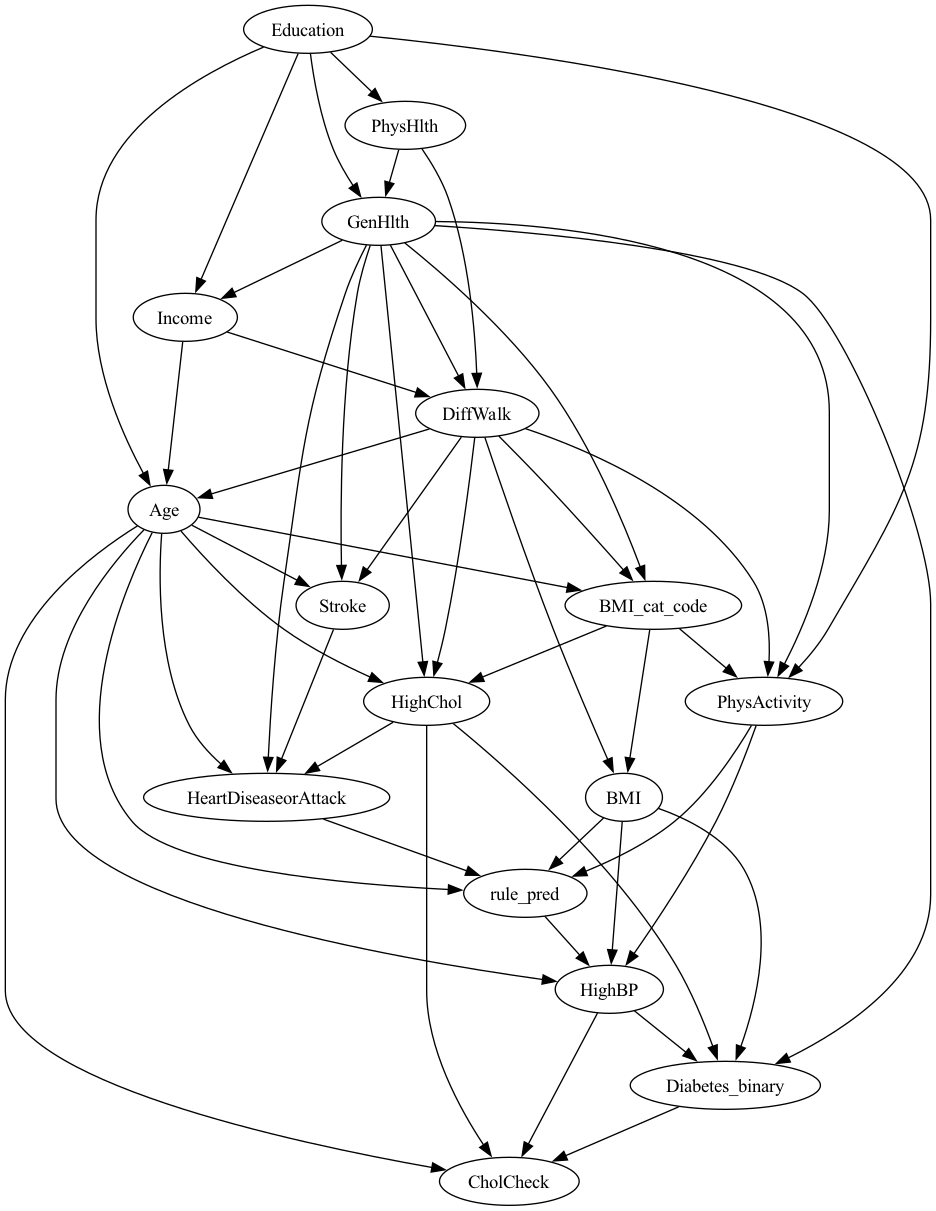

In [93]:
# Convert learned model into pygraphviz object
model_graphviz = estimated_model.to_graphviz()

# Save in multiple formats
model_graphviz.draw("learned_structure.png", prog="dot")
model_graphviz.draw("learned_structure.pdf", prog="dot")
model_graphviz.draw("learned_structure.svg", prog="dot")

# Verify files were created
import os, glob
print("cwd:", os.getcwd())
print("created:", glob.glob("learned_structure.*"))

# Display inline (Jupyter)
from IPython.display import Image, display
display(Image("learned_structure.png"))
